In [590]:
import pandas
import copy
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import seaborn as sbn
import sys
import matplotlib.pyplot as plt


# show all elements of a dataframe
# pandas.set_option("display.max_rows", None)
pandas.set_option("display.max_columns", None)


sys.path.append("../../src/")

In [591]:
races = pd.read_csv('../dataset/preprocessedRaces.csv', sep=",")
races.head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta
0,tour-de-france/1978/stage-6,Tour de France,100,NaN,162000,1101,1.0,1241,NaN,1,0,0,1978-07-05,0.006796,27.0,6.847590
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,100.0,196000,5575,5.0,821,NaN,1,0,0,2016-09-03,0.028444,1957.0,873.835670
2,tour-de-france/2019/stage-21,Tour de France,100,120.0,128000,781,1.0,1699,NaN,1,0,0,2019-07-28,0.006102,29.0,44.079531
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,NaN,8100,68,NaN,804,NaN,1,0,0,1999-06-17,0.008395,53.0,27.154498
4,tour-de-france/2022/stage-9,Tour de France,100,120.0,192900,3743,3.0,1551,24.0,1,0,0,2022-07-10,0.019404,1376.0,675.354230


In [592]:
races.isna().sum()

_url                      0
name                      0
points                    0
uci_points             3682
length                    0
climb_total               0
profile                2408
startlist_quality         0
average_temperature    5076
is_tarmac                 0
is_cobbled                0
is_gravel                 0
date                      0
climb/length              0
median_delta              0
std_delta                 0
dtype: int64

In [593]:
races.dtypes

_url                    object
name                    object
points                   int64
uci_points             float64
length                   int64
climb_total              int64
profile                float64
startlist_quality        int64
average_temperature    float64
is_tarmac                int64
is_cobbled               int64
is_gravel                int64
date                    object
climb/length           float64
median_delta           float64
std_delta              float64
dtype: object

In [594]:
cyclists = pd.read_csv('../dataset/preprocessedCyclists.csv', sep=",")
cyclists.head()

,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position
0,sean-kelly,23.770000,6,16,629,Ireland,Europe,Northern Europe,1956.0,22,11.0,7.0,22.0,20.0,8.0,10.0,23.0,18.0,24.497844
1,gerrie-knetemann,19.959003,38,48,271,Netherlands,Europe,Western Europe,1951.0,66,56.0,15.0,58.0,NaN,15.0,18.0,66.0,NaN,46.993017
2,rene-bittinger,22.790000,42,47,146,France,Europe,Western Europe,1954.0,54,15.0,31.0,55.0,NaN,17.0,37.0,56.0,18.0,32.648452
3,joseph-bruyere,23.086015,8,16,48,Belgium,Europe,Western Europe,1948.0,21,29.0,11.0,19.0,NaN,5.0,14.0,23.0,NaN,19.723611
4,sven-ake-nilsson,21.300000,25,33,145,Sweden,Europe,Northern Europe,1951.0,38,17.0,12.0,38.0,NaN,14.0,27.0,37.0,16.0,26.276978


In [595]:
cyclists.isna().sum()

name                        0
BMI                         0
median position             0
AVG position                0
# cyclist races             0
nationality                 0
continent                   0
geo area                    0
birth_year                  0
AVG weighted position       0
AVG position Autumn      2879
AVG position Spring       737
AVG position Summer      1945
AVG position Winter      4523
AVG position Q1          1694
AVG position Q2          1023
AVG position Q3          2280
AVG position Q4          4270
std_dev position            0
dtype: int64

In [596]:
cyclists.dtypes

name                      object
BMI                      float64
median position            int64
AVG position               int64
# cyclist races            int64
nationality               object
continent                 object
geo area                  object
birth_year               float64
AVG weighted position      int64
AVG position Autumn      float64
AVG position Spring      float64
AVG position Summer      float64
AVG position Winter      float64
AVG position Q1          float64
AVG position Q2          float64
AVG position Q3          float64
AVG position Q4          float64
std_dev position         float64
dtype: object

In [597]:
placements = pd.read_csv('../dataset/preprocessedPlacements.csv', sep=",")
placements.head()

,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,year
0,0,georges-pintens,24,norway-1987,0,1970-04-25,amstel-gold-race/1970/result,1970
1,1,willy-van-neste,26,norway-1987,0,1970-04-25,amstel-gold-race/1970/result,1970
2,2,andre-dierickx,23,spain-1991,22,1970-04-25,amstel-gold-race/1970/result,1970
3,3,eric-leman,24,spain-1991,33,1970-04-25,amstel-gold-race/1970/result,1970
4,4,joseph-schoeters,23,NaN,33,1970-04-25,amstel-gold-race/1970/result,1970


In [598]:
placements.isna().sum()

position             0
cyclist              0
cyclist_age          0
cyclist_team    159161
delta                0
date                 0
_url                 0
year                 0
dtype: int64

In [599]:
placements.dtypes

position         int64
cyclist         object
cyclist_age      int64
cyclist_team    object
delta            int64
date            object
_url            object
year             int64
dtype: object

# Clustering for cyclists

## Outliers Detection

In [600]:
def show_hist_and_box_plot(dataframe, column_name):
    column = dataframe[column_name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram 
    sbn.histplot(column, bins='sturges', ax=axes[0])
    axes[0].set_title(f'Histogram of {column.name}', fontweight='bold')
    axes[0].set_xlabel(column.name) 
    axes[0].set_ylabel('Frequency')
    
    # Boxplot
    boxplot_dict = axes[1].boxplot(column[~np.isnan(column)])  # Removes the NaNs to avoid problems
    axes[1].set_title(f'Boxplot of {column.name}', fontweight='bold')
    axes[1].set_xlabel(column.name)
    
    # Extraction of the outliers from the boxplot and printing of them
    outliers = [flier.get_ydata() for flier in boxplot_dict['fliers']]
    outliers_values = list({value for sublist in outliers for value in sublist})

    plt.tight_layout()  # Avoid overlapping
    plt.show()

    print(f"Outliers in {column.name}: {outliers_values}")

In [601]:
def calculate_outlier_bounds(dataframe, column_name):
    Q1 = dataframe[column_name].quantile(0.25)
    Q3 = dataframe[column_name].quantile(0.75)
    IQR = Q3 - Q1
    min_ = dataframe[column_name].min()
    max_ = dataframe[column_name].max()
    lower_bound = max(min_, Q1 - 1.5 * IQR)
    upper_bound = min(max_, Q3 + 1.5 * IQR)
    return {"lower": lower_bound, "upper": upper_bound}

Feature selection based on NAN values and high correlation

In [602]:
numerical_cols = cyclists.select_dtypes(include=['float64', 'int64', 'Int64']).columns
numeric_cyclists_df = cyclists[numerical_cols]
numeric_cyclists_df

,BMI,median position,AVG position,# cyclist races,birth_year,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position
0,23.770000,6,16,629,1956.0,22,11.0,7.0,22.0,20.0,8.0,10.0,23.0,18.0,24.497844
1,19.959003,38,48,271,1951.0,66,56.0,15.0,58.0,NaN,15.0,18.0,66.0,NaN,46.993017
2,22.790000,42,47,146,1954.0,54,15.0,31.0,55.0,NaN,17.0,37.0,56.0,18.0,32.648452
3,23.086015,8,16,48,1948.0,21,29.0,11.0,19.0,NaN,5.0,14.0,23.0,NaN,19.723611
4,21.300000,25,33,145,1951.0,38,17.0,12.0,38.0,NaN,14.0,27.0,37.0,16.0,26.276978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6090,19.696783,173,173,1,1969.0,173,NaN,173.0,NaN,NaN,173.0,NaN,NaN,NaN,0.000000
6091,20.031931,17,17,1,1965.0,17,NaN,17.0,NaN,NaN,17.0,NaN,NaN,NaN,0.000000
6092,25.450000,54,54,1,1992.0,54,NaN,NaN,54.0,NaN,NaN,NaN,54.0,NaN,0.000000
6093,20.011635,38,38,1,1948.0,38,NaN,38.0,NaN,NaN,38.0,NaN,NaN,NaN,0.000000


In [603]:
numeric_cyclists_df = numeric_cyclists_df[['BMI', 'median position', '# cyclist races', 'birth_year', 'std_dev position']]
numeric_cyclists_df

,BMI,median position,# cyclist races,birth_year,std_dev position
0,23.770000,6,629,1956.0,24.497844
1,19.959003,38,271,1951.0,46.993017
2,22.790000,42,146,1954.0,32.648452
3,23.086015,8,48,1948.0,19.723611
4,21.300000,25,145,1951.0,26.276978
...,...,...,...,...,...
6090,19.696783,173,1,1969.0,0.000000
6091,20.031931,17,1,1965.0,0.000000
6092,25.450000,54,1,1992.0,0.000000
6093,20.011635,38,1,1948.0,0.000000


,BMI,median position,# cyclist races,birth_year,std_dev position
BMI,1.000000,0.007206,-0.022857,-0.134499,0.048828
median position,0.007206,1.000000,-0.080105,0.486306,0.258890
# cyclist races,-0.022857,-0.080105,1.000000,0.161916,0.356324
birth_year,-0.134499,0.486306,0.161916,1.000000,0.248989
std_dev position,0.048828,0.258890,0.356324,0.248989,1.000000


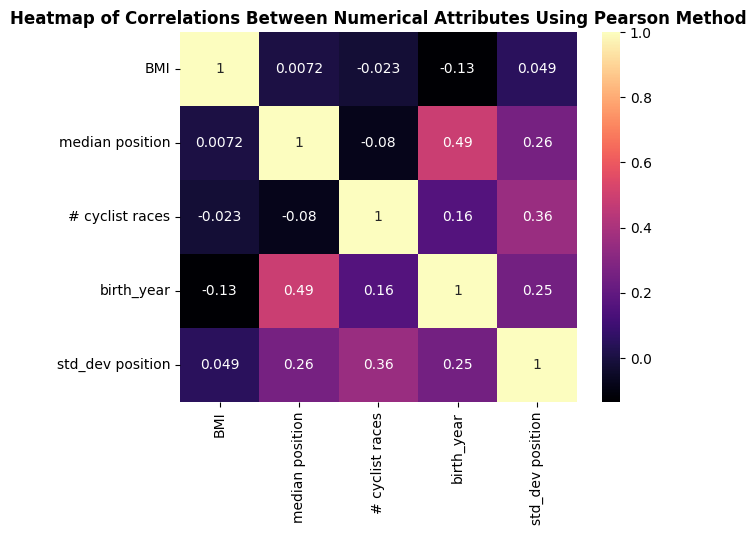

In [604]:
pearson_matrix = numeric_cyclists_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

For the outliers detection we need the field _\_name_ as identifier

In [605]:
numeric_columns = numeric_cyclists_df.columns
numeric_cyclists_df = numeric_cyclists_df.copy()
numeric_cyclists_df['name'] = cyclists['name']

We will now display the distributions of the selected columns and address the most extreme outliers based on these initial distributions, essentially taking a snapshot of the initial state of the dataframe _numeric\_cyclists\_df_. We will not adopt a cumulative approach, where the removal of outliers from one column would affect the subsequent distributions of the other columns

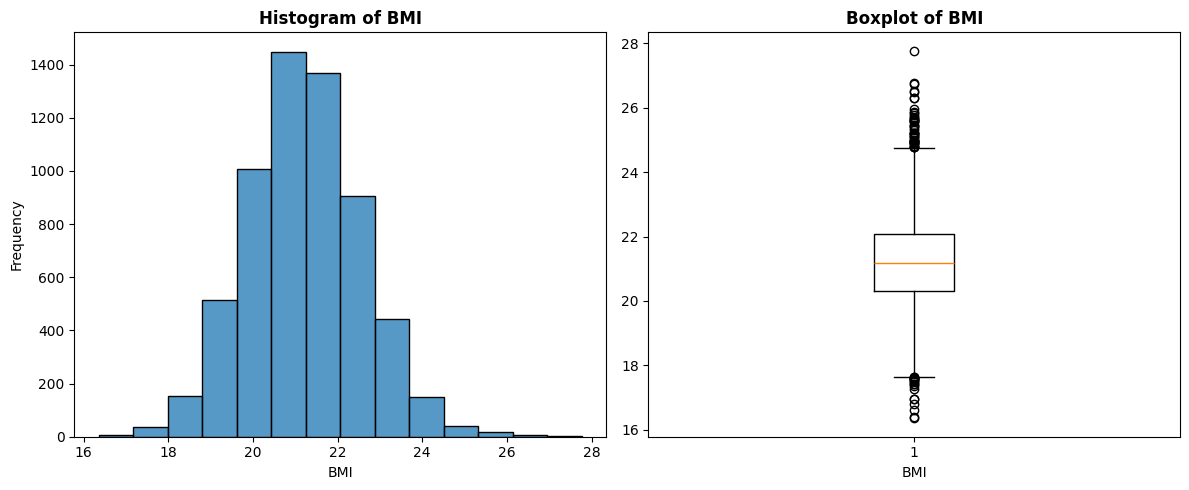

Outliers in BMI: [np.float64(25.20022254995826), np.float64(26.49), np.float64(26.78), np.float64(26.3), np.float64(24.807923763767764), np.float64(25.36941027818859), np.float64(27.77), np.float64(26.29494847074345), np.float64(25.607467548760734), np.float64(24.96), np.float64(25.95), np.float64(16.41), np.float64(17.364928022068078), np.float64(16.6), np.float64(16.96844793244452), np.float64(17.565204979689348), np.float64(17.412665529606812), np.float64(17.612939045572052), np.float64(17.62), np.float64(17.51), np.float64(17.263427240941304), np.float64(17.43167412484733), np.float64(26.53), np.float64(25.66), np.float64(25.14), np.float64(25.43), np.float64(25.31), np.float64(26.75), np.float64(25.22), np.float64(25.76), np.float64(24.78), np.float64(24.911001262515327), np.float64(24.97), np.float64(24.91), np.float64(25.59), np.float64(25.88), np.float64(25.83), np.float64(25.01), np.float64(24.786893547252976), np.float64(25.1), np.float64(24.954337414105275), np.float64(25.12

,Name,Column,Lower Bound,Upper Bound,Outlier Value
14,javier-francisco-elorriaga,BMI,17.64,24.76,26.53
27,marc-demeyer,BMI,17.64,24.76,25.66
241,svein-tuft,BMI,17.64,24.76,25.14
466,massimiliano-mori,BMI,17.64,24.76,25.43
565,john-degenkolb,BMI,17.64,24.76,25.31
...,...,...,...,...,...
5800,paul-willerton,BMI,17.64,24.76,16.35
5889,brian-petersen,BMI,17.64,24.76,25.20
6001,marc-de-block,BMI,17.64,24.76,24.87
6085,bjorn-backmann,BMI,17.64,24.76,25.61


Number of outliers in BMI: 66


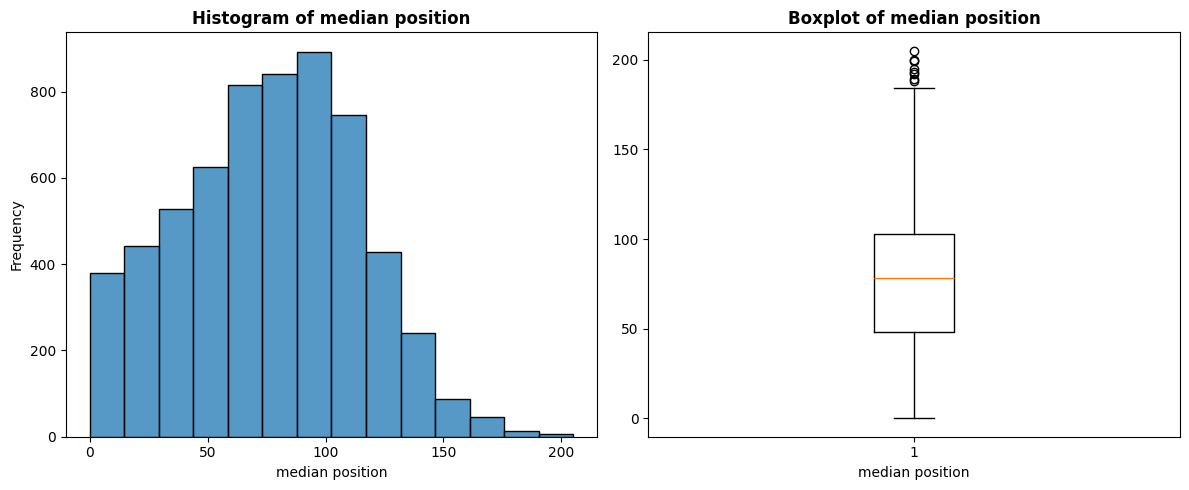

Outliers in median position: [np.int64(192), np.int64(193), np.int64(195), np.int64(199), np.int64(200), np.int64(205), np.int64(188), np.int64(189)]


,Name,Column,Lower Bound,Upper Bound,Outlier Value
5134,chris-barton,median position,0,185.5,205
5179,renan-ferraro,median position,0,185.5,188
5289,ramon-carretero,median position,0,185.5,192
5404,pedro-autran-dourado-dutra-nicacio,median position,0,185.5,193
5405,gabriel-machado-silva,median position,0,185.5,195
5477,sergio-jaramillo,median position,0,185.5,200
5674,rik-van-ijzendoorn,median position,0,185.5,189
5926,vadim-kravchenko,median position,0,185.5,199


Number of outliers in median position: 8


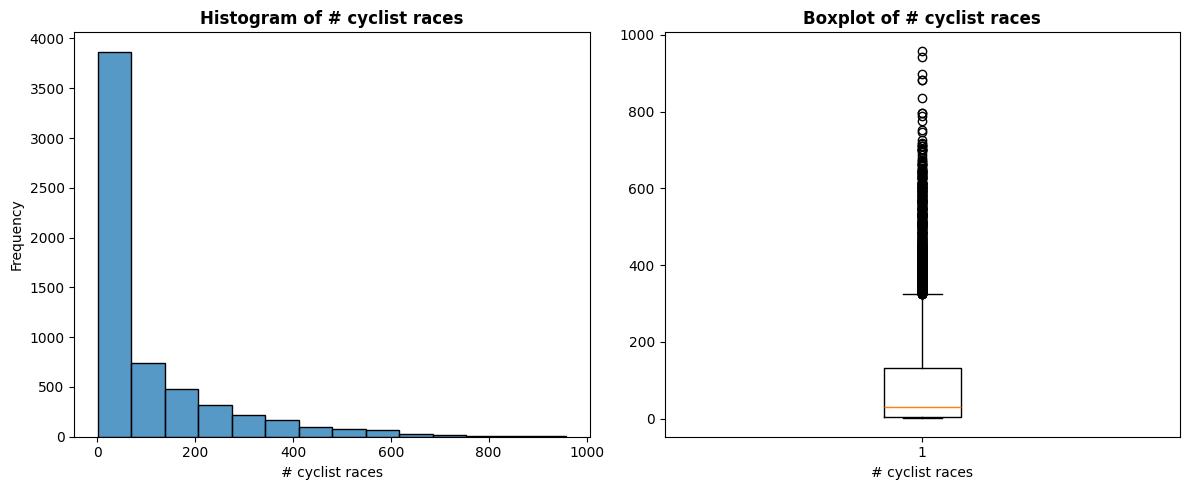

Outliers in # cyclist races: [np.int64(512), np.int64(513), np.int64(514), np.int64(515), np.int64(518), np.int64(519), np.int64(520), np.int64(522), np.int64(526), np.int64(527), np.int64(528), np.int64(529), np.int64(530), np.int64(531), np.int64(533), np.int64(534), np.int64(535), np.int64(537), np.int64(538), np.int64(544), np.int64(545), np.int64(546), np.int64(547), np.int64(549), np.int64(550), np.int64(552), np.int64(554), np.int64(556), np.int64(557), np.int64(559), np.int64(562), np.int64(563), np.int64(564), np.int64(565), np.int64(567), np.int64(568), np.int64(569), np.int64(570), np.int64(571), np.int64(574), np.int64(575), np.int64(576), np.int64(577), np.int64(581), np.int64(582), np.int64(583), np.int64(585), np.int64(587), np.int64(590), np.int64(591), np.int64(592), np.int64(594), np.int64(595), np.int64(597), np.int64(598), np.int64(600), np.int64(601), np.int64(603), np.int64(605), np.int64(606), np.int64(608), np.int64(609), np.int64(610), np.int64(612), np.int64(6

,Name,Column,Lower Bound,Upper Bound,Outlier Value
0,sean-kelly,# cyclist races,1,325.0,629
37,henk-lubberding,# cyclist races,1,325.0,346
56,joop-zoetemelk,# cyclist races,1,325.0,334
106,robert-gesink,# cyclist races,1,325.0,653
107,kenny-elissonde,# cyclist races,1,325.0,386
...,...,...,...,...,...
2701,marc-sergeant,# cyclist races,1,325.0,338
2708,steven-rooks,# cyclist races,1,325.0,332
2843,kim-kirchen,# cyclist races,1,325.0,329
2941,vladimir-gusev,# cyclist races,1,325.0,359


Number of outliers in # cyclist races: 530


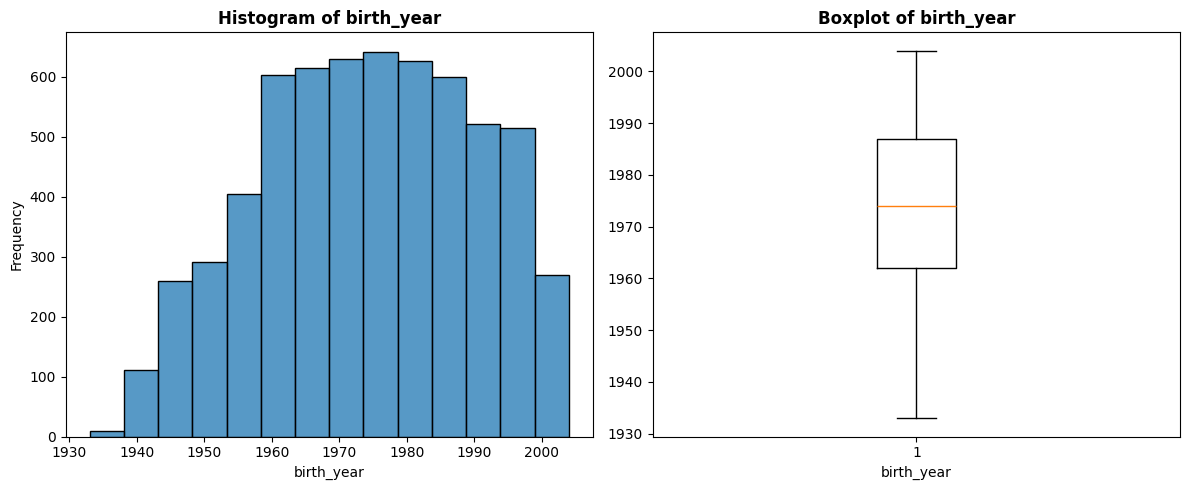

Outliers in birth_year: []
Number of outliers in birth_year: 0


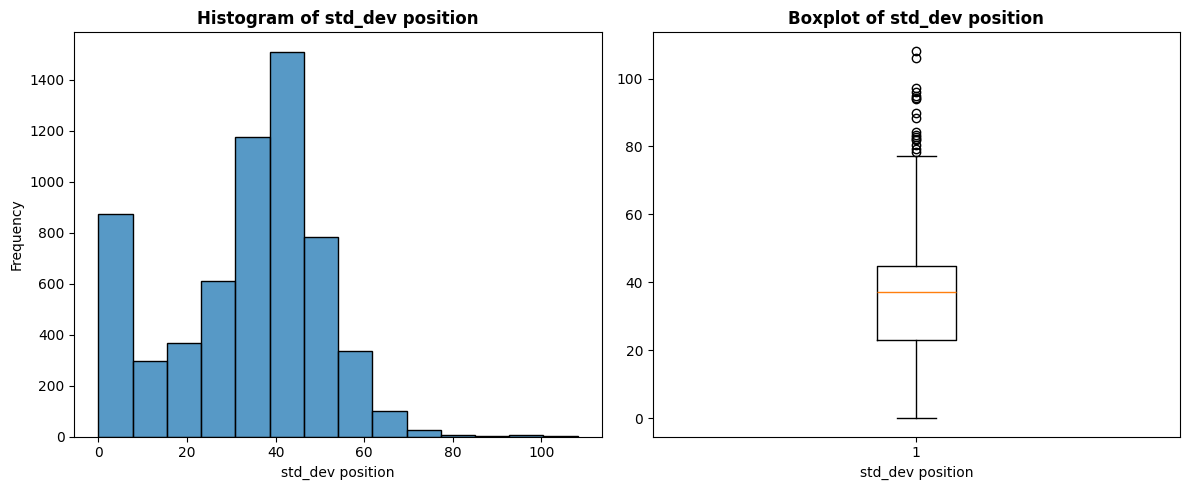

Outliers in std_dev position: [np.float64(96.16652224137046), np.float64(97.2745256135096), np.float64(106.06601717798212), np.float64(108.18733752154178), np.float64(78.48885271170677), np.float64(79.19595949289332), np.float64(80.49016503068351), np.float64(94.75230867899737), np.float64(81.94103571064582), np.float64(82.92365967161201), np.float64(84.11809879838313), np.float64(82.2455672564384), np.float64(83.43860018001261), np.float64(88.38834764831844), np.float64(89.77740329758454), np.float64(94.04520189781084), np.float64(94.40868604106298)]


,Name,Column,Lower Bound,Upper Bound,Outlier Value
2629,santiago-portillo-rosado,std_dev position,0.0,77.57,94.41
3820,lech-piasecki,std_dev position,0.0,77.57,84.12
3834,paul-watson,std_dev position,0.0,77.57,89.78
4432,nikolai-galitchanin,std_dev position,0.0,77.57,108.19
4905,sergei-sukhoruchenkov,std_dev position,0.0,77.57,97.27
5381,sylvain-bolay,std_dev position,0.0,77.57,94.75
5401,jose-inguanzo,std_dev position,0.0,77.57,106.07
5416,rustam-tukhvatulin,std_dev position,0.0,77.57,81.94
5430,michele-merlo,std_dev position,0.0,77.57,82.92
5475,pedro-jose-soler,std_dev position,0.0,77.57,79.20


Number of outliers in std_dev position: 17


In [606]:
for column in numeric_columns:
    show_hist_and_box_plot(numeric_cyclists_df,column)
    bounds = calculate_outlier_bounds(numeric_cyclists_df, column)
    lower_bound = round(bounds['lower'], 2)
    upper_bound = round(bounds['upper'], 2)
    
    outliers_list = []
    outliers = numeric_cyclists_df[
        (numeric_cyclists_df[column] < lower_bound) | (numeric_cyclists_df[column] > upper_bound)
    ]

    column_outliers_count = len(outliers)

    column_outliers_df = pd.DataFrame({
        "Name": outliers['name'],
        "Column": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Value": outliers[column].round(2)
    })
    if(column_outliers_count > 0):
        display(column_outliers_df)
    print(f"Number of outliers in {column}: {column_outliers_count}")

In [607]:
def check_all_outliers(df):
    # Crea un DataFrame per tracciare gli outliers per ogni riga
    outlier_flags = pd.DataFrame(index=df.index)

    for column in numeric_columns:
        # Calcola i bounds
        bounds = calculate_outlier_bounds(df, column)
        lower_bound = bounds['lower']
        upper_bound = bounds['upper']
        
        # Flagga le righe con outliers nella colonna corrente
        outlier_flags[column] = (df[column] < lower_bound) | (df[column] > upper_bound)

    # Conta il numero di colonne con outliers per ogni riga
    outlier_flags['outlier_count'] = outlier_flags.sum(axis=1)


    # Calcola la percentuale di colonne con outliers per ogni riga
    outlier_flags['outlier_percentage'] = (outlier_flags['outlier_count'] / len(numeric_columns)) * 100

    # Mostra solo le righe con almeno un outlier
    rows_with_outliers = outlier_flags[outlier_flags['outlier_count'] > 0]

    display(rows_with_outliers)

    # Output statistico
    print(f"Total rows with outliers: {len(rows_with_outliers)}")
    print(f"Percentage of rows with outliers: {(len(rows_with_outliers) / len(df)) * 100:.2f}%")

    return rows_with_outliers

In [608]:
rows_with_outliers = check_all_outliers(numeric_cyclists_df)

,BMI,median position,# cyclist races,birth_year,std_dev position,outlier_count,outlier_percentage
0,False,False,True,False,False,1,20.0
14,True,False,False,False,False,1,20.0
27,True,False,False,False,False,1,20.0
37,False,False,True,False,False,1,20.0
56,False,False,True,False,False,1,20.0
...,...,...,...,...,...,...,...
5926,False,True,False,False,False,1,20.0
5971,False,False,False,False,True,1,20.0
6001,True,False,False,False,False,1,20.0
6085,True,False,False,False,False,1,20.0


Total rows with outliers: 618
Percentage of rows with outliers: 10.14%


In [609]:
rows_with_outliers[rows_with_outliers['outlier_count'] > 1]


,BMI,median position,# cyclist races,birth_year,std_dev position,outlier_count,outlier_percentage
241,True,False,True,False,False,2,40.0
565,True,False,True,False,False,2,40.0
1166,True,False,True,False,False,2,40.0


### Outliers elimination


#### _# cyclist races_ (530): complete outlier removal

Let's try to adopt this approach with the column _# cyclist races_, which has the highest number of outliers. We start by simply eliminating all the outliers for this column.

In [610]:
def outliers_removal(df_for_distribution, column, df):
    bound = calculate_outlier_bounds(df_for_distribution, column)
    lower_bound = bound['lower']
    upper_bound = bound['upper']

    cleaned_df = df[
        (df[column] >= lower_bound) & (df[column] <= upper_bound)
    ]
    print(f"Remaining rows after removal: {len(cleaned_df)}")
    print(f"Removed rows: {len(df) - len(cleaned_df)}")

    return {"cleaned_df":cleaned_df, "lower_bound": lower_bound, "upper_bound": upper_bound}

In [611]:
outliers_removal_obj = outliers_removal(numeric_cyclists_df,"# cyclist races", numeric_cyclists_df)
lower_bound_n_cyclist_races = outliers_removal_obj['lower_bound']
upper_bound_n_cyclist_races = outliers_removal_obj['upper_bound']
cleaned_cyclists_df = outliers_removal_obj['cleaned_df']

Remaining rows after removal: 5565
Removed rows: 530


In [612]:
def compare_box_plots(dataframe1, dataframe2, column_name):
    column1 = dataframe1[column_name]
    column2 = dataframe2[column_name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Boxplot1
    boxplot_dict = axes[0].boxplot(column1[~np.isnan(column1)])  # Removes the NaNs to avoid problems
    axes[0].set_title(f'Boxplot before outliers cleaning', fontweight='bold')
    axes[0].set_xlabel(column1.name)

    # Boxplot2
    boxplot_dict = axes[1].boxplot(column2[~np.isnan(column2)])  # Removes the NaNs to avoid problems
    axes[1].set_title(f'Boxplot after outliers cleaning', fontweight='bold')
    axes[1].set_xlabel(column2.name)


    plt.tight_layout() 
    plt.show()


In [613]:
def compare_distributions(dataframe1, dataframe2, column_name):
    column1 = dataframe1[column_name]
    column2 = dataframe2[column_name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
   
    # Histogram1 
    sbn.histplot(column1, bins='sturges', ax=axes[0])
    axes[0].set_title(f'Histogram before outliers cleaning', fontweight='bold')
    axes[0].set_xlabel(column1.name) 
    axes[0].set_ylabel('Frequency')

    #Histogram2
    sbn.histplot(column2, bins='sturges', ax=axes[1])
    axes[1].set_title(f'Histogram after outliers cleaning', fontweight='bold')
    axes[1].set_xlabel(column2.name) 
    axes[1].set_ylabel('Frequency')


    plt.tight_layout() 
    plt.show()


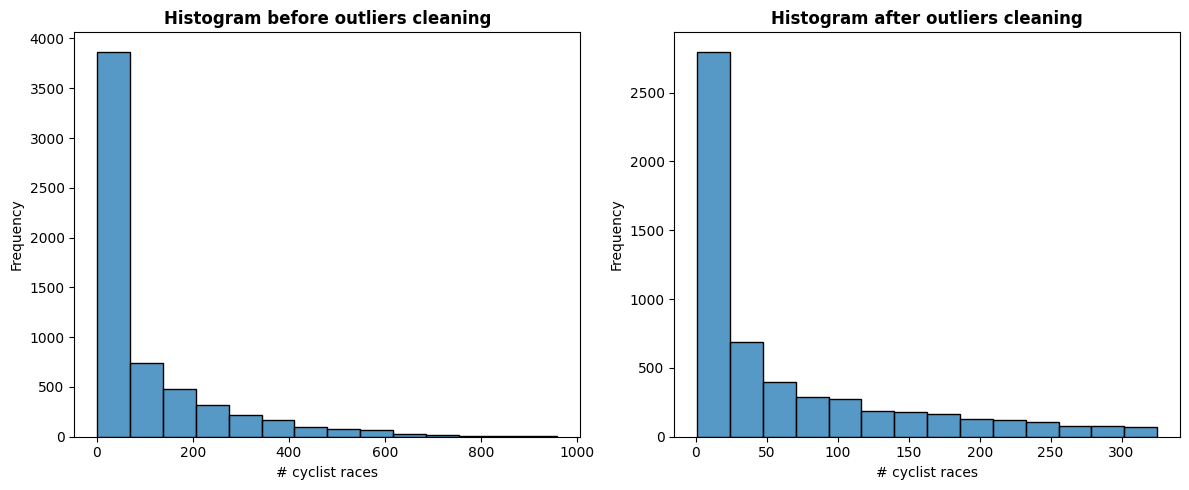

In [614]:
compare_distributions(numeric_cyclists_df, cleaned_cyclists_df, "# cyclist races")

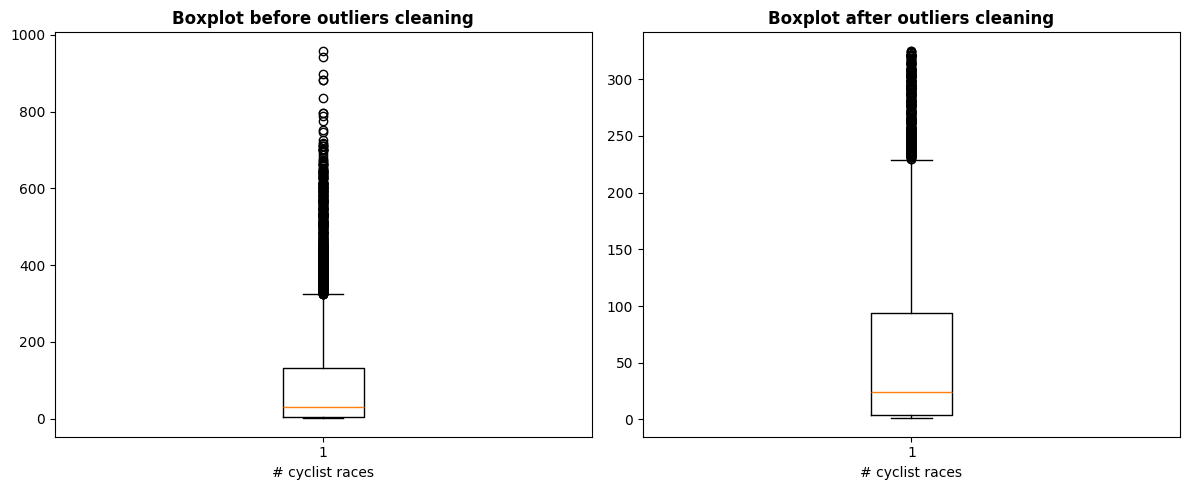

In [615]:
compare_box_plots(numeric_cyclists_df, cleaned_cyclists_df, "# cyclist races")


In this approach, as shown in the above distribution and box plot graphs, removing all 530 outliers of the _# cyclist race_ column, resulted in significant alterations to the data, making this method less suitable for preserving the original distribution

#### _# cyclist races_ (530): removal of extreme outliers
We evaluate different ranges of values (in increments of 200) above the upper bound, selecting a reasonable threshold beyond which outliers are considered extreme

In [616]:
column = "# cyclist races"
outliers = numeric_cyclists_df[
    (numeric_cyclists_df[column] < lower_bound_n_cyclist_races) | (numeric_cyclists_df[column] > upper_bound_n_cyclist_races)
]

column_outliers_count = len(outliers)


# Crea il DataFrame degli outliers
column_outliers_df = pd.DataFrame({
    "Name": outliers['name'],
    "Column": column,
    "Lower Bound": lower_bound_n_cyclist_races,
    "Upper Bound": upper_bound_n_cyclist_races,
    "Outlier Value": outliers[column].round(2)
})


range_1 = upper_bound_n_cyclist_races + 200
range_2 = range_1 + 100
range_3 = range_2 + 100
range_4 = range_3 + 100
range_5 = range_4 + 100
range_6 = range_5 + 100
range_7 = range_6 + 100


outliers_range_1 = column_outliers_df[column_outliers_df['Outlier Value'] < range_1 ]
outliers_range_2 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_1) & (column_outliers_df['Outlier Value'] < range_2)]
outliers_range_3 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_2) & (column_outliers_df['Outlier Value'] < range_3)]
outliers_range_4 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_3) & (column_outliers_df['Outlier Value'] < range_4)]
outliers_range_5 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_4) & (column_outliers_df['Outlier Value'] < range_5)]
outliers_range_6 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_5) & (column_outliers_df['Outlier Value'] < range_6)]
outliers_range_7 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_6) & (column_outliers_df['Outlier Value'] < range_7)]
outliers_range_8 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_7)]

print(f"Number of outliers in the range of [{upper_bound_n_cyclist_races}, {range_1}]: {len(outliers_range_1)}")
print(f"Number of outliers in the range of [{range_1}, {range_2}]: {len(outliers_range_2)}")
print(f"Number of outliers in the range of [{range_2}, {range_3}]: {len(outliers_range_3)}")
print(f"Number of outliers in the range of [{range_3}, {range_4}]: {len(outliers_range_4)}")
print(f"Number of outliers in the range of [{range_4}, {range_5}]: {len(outliers_range_5)}")
print(f"Number of outliers in the range of [{range_5}, {range_6}]: {len(outliers_range_6)}")
print(f"Number of outliers in the range of [{range_6}, {range_7}]: {len(outliers_range_7)}")


print(f"Number of outliers > {range_7}: {len(outliers_range_8)}")

Number of outliers in the range of [325.0, 525.0]: 377
Number of outliers in the range of [525.0, 625.0]: 97
Number of outliers in the range of [625.0, 725.0]: 43
Number of outliers in the range of [725.0, 825.0]: 7
Number of outliers in the range of [825.0, 925.0]: 4
Number of outliers in the range of [925.0, 1025.0]: 2
Number of outliers in the range of [1025.0, 1125.0]: 0
Number of outliers > 1125.0: 0


We choose a value between [525, 725], which provides a good compromise for removing a significant number of outliers without overly altering the initial distribution. A value of 600 appears to be the most appropriate.

In [617]:
len(column_outliers_df[column_outliers_df['Outlier Value'] > 600])

73

For better statistical precision, we rely on a quartile value that is close to 600. It is about the 98nd percentile.

In [618]:
Q4 = numeric_cyclists_df["# cyclist races"].quantile(0.98)
Q4

np.float64(549.1199999999999)

In [619]:
cleaned_cyclists_df = numeric_cyclists_df.copy()  

cleaned_cyclists_df = cleaned_cyclists_df[
    (cleaned_cyclists_df['# cyclist races'] <=  Q4)
]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len(numeric_cyclists_df) - len(cleaned_cyclists_df)}")

Remaining rows after removal: 5973
Removed rows: 122


As shown in the below distribution and box plot graphs for the _# cyclist races_ column, the cleaned data does not deviate significantly from the original values. The core structure and range of this column remain consistent, while the most extreme outliers (> 600) have been effectively removed. This ensures that the cleaning process focused specifically on this column without distorting its overall characteristics.

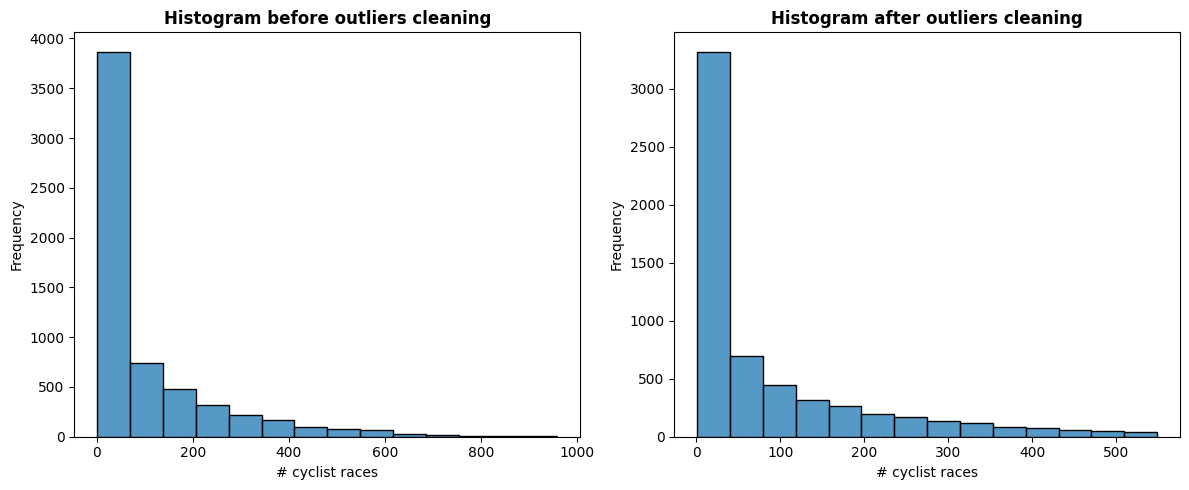

In [620]:
compare_distributions(numeric_cyclists_df, cleaned_cyclists_df, "# cyclist races")

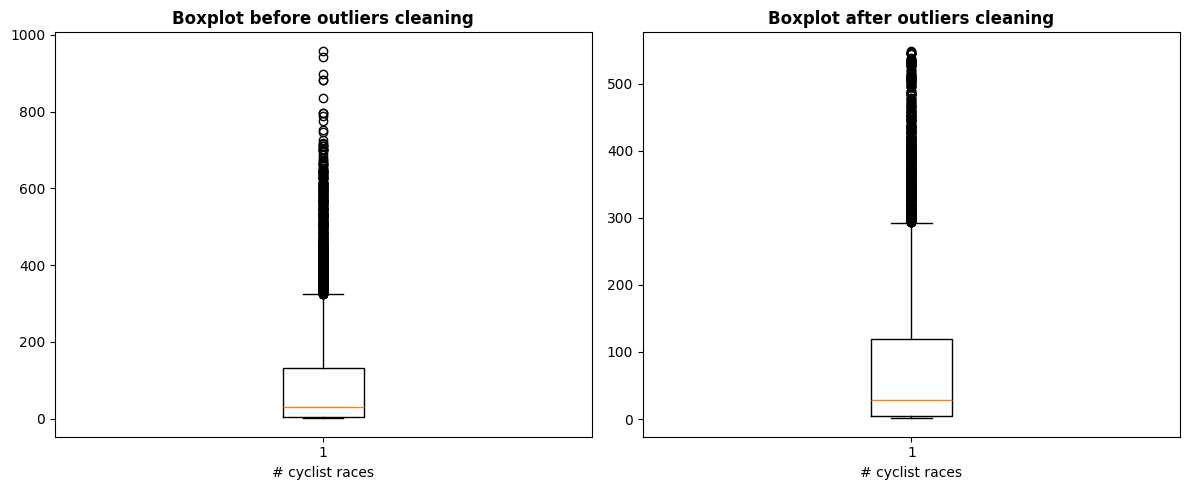

In [621]:
compare_box_plots(numeric_cyclists_df, cleaned_cyclists_df, "# cyclist races")

In [622]:
cleaned_cyclists_df
print(len(numeric_cyclists_df))
print(len(cleaned_cyclists_df))



6095
5973


#### BMI (66)


In [623]:
outliers_removal_obj = outliers_removal(numeric_cyclists_df, "BMI", cleaned_cyclists_df)
lower_bound_BMI = outliers_removal_obj['lower_bound']
upper_bound_BMI = outliers_removal_obj['upper_bound']   
res_cleaned_df = outliers_removal_obj['cleaned_df']


Remaining rows after removal: 5907
Removed rows: 66


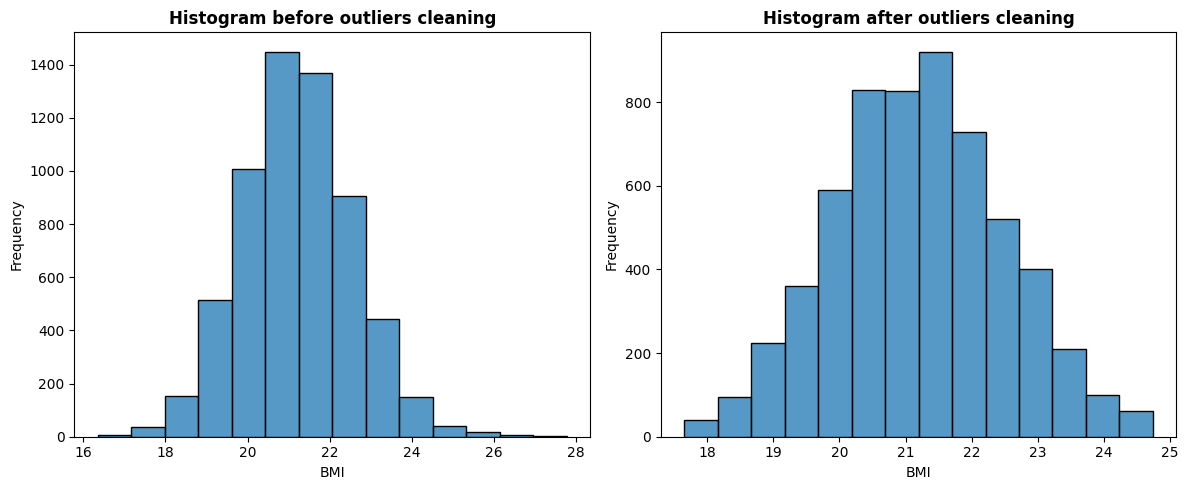

In [624]:
compare_distributions(numeric_cyclists_df, res_cleaned_df, "BMI")

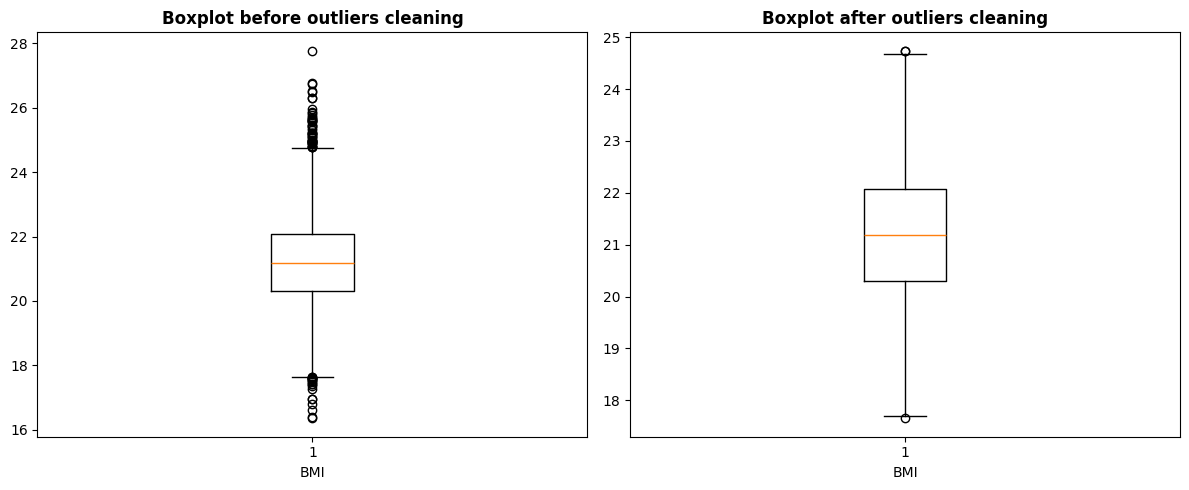

In [625]:
compare_box_plots(numeric_cyclists_df, res_cleaned_df, "BMI")

In [626]:
lower_bound_BMI

np.float64(17.639999999999997)

In [627]:
upper_bound_BMI

np.float64(24.76)

In [628]:
column = "BMI"
outliers = numeric_cyclists_df[
    (numeric_cyclists_df[column] < lower_bound_BMI) | (numeric_cyclists_df[column] > upper_bound_BMI)
]

outliers_above = outliers[outliers[column] > upper_bound_BMI]
outliers_below = outliers[outliers[column] < lower_bound_BMI]

print(f"Outliers above upper bound ({upper_bound_BMI}): {len(outliers_above)}")
print(f"Outliers below lower bound ({lower_bound_BMI}): {len(outliers_below)}")
print(f"Total outliers: {len(outliers_above) + len(outliers_below)}")


column_outliers_df = pd.DataFrame({
    "Name": outliers['name'],
    "Column": column,
    "Lower Bound": lower_bound_BMI,
    "Upper Bound": upper_bound_BMI,
    "Outlier Value": outliers[column].round(2)
})

range_above_1 = upper_bound_BMI + 0.5
range_above_2 = range_above_1 + 0.5
range_above_3 = range_above_2 + 0.5
range_above_4 = range_above_3 + 0.5

outliers_above_range_1 = column_outliers_df[(column_outliers_df['Outlier Value'] >= upper_bound_BMI) & (column_outliers_df['Outlier Value'] < range_above_1)]
outliers_above_range_2 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_above_1) & (column_outliers_df['Outlier Value'] < range_above_2)]
outliers_above_range_3 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_above_2) & (column_outliers_df['Outlier Value'] < range_above_3)]
outliers_above_range_4 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_above_3) & (column_outliers_df['Outlier Value'] < range_above_4)]
outliers_above_range_5 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_above_4)]


range_below_1 = lower_bound_BMI - 0.5
range_below_2 = range_below_1 - 0.5
range_below_3 = range_below_2 - 0.5

outliers_below_range_1 = column_outliers_df[(column_outliers_df['Outlier Value'] < lower_bound_BMI) & (column_outliers_df['Outlier Value'] >= range_below_1)]
outliers_below_range_2 = column_outliers_df[(column_outliers_df['Outlier Value'] < range_below_1) & (column_outliers_df['Outlier Value'] >= range_below_2)]
outliers_below_range_3 = column_outliers_df[(column_outliers_df['Outlier Value'] < range_below_2) & (column_outliers_df['Outlier Value'] >= range_below_3)]
outliers_below_range_4 = column_outliers_df[(column_outliers_df['Outlier Value'] < range_below_3)]

# Stampa dei risultati per i range sopra l'upper bound
print(f"Number of outliers in the range of [{upper_bound_BMI}, {range_above_1}]: {len(outliers_above_range_1)}")
print(f"Number of outliers in the range of [{range_above_1}, {range_above_2}]: {len(outliers_above_range_2)}")
print(f"Number of outliers in the range of [{range_above_2}, {range_above_3}]: {len(outliers_above_range_3)}")
print(f"Number of outliers in the range of [{range_above_3}, {range_above_4}]: {len(outliers_above_range_4)}")
print(f"Number of outliers > {range_above_4}: {len(outliers_above_range_5)}")

print("\n")

# Stampa dei risultati per i range sotto il lower bound
print(f"Number of outliers in the range of [{range_below_1}, {lower_bound_BMI}]: {len(outliers_below_range_1)}")
print(f"Number of outliers in the range of [{range_below_2}, {range_below_1}]: {len(outliers_below_range_2)}")
print(f"Number of outliers in the range of [{range_below_3}, {range_below_2}]: {len(outliers_below_range_3)}")
print(f"Number of outliers < {range_below_3}: {len(outliers_below_range_4)}")

Outliers above upper bound (24.76): 46
Outliers below lower bound (17.639999999999997): 20
Total outliers: 66
Number of outliers in the range of [24.76, 25.26]: 22
Number of outliers in the range of [25.26, 25.76]: 13
Number of outliers in the range of [25.76, 26.26]: 4
Number of outliers in the range of [26.26, 26.76]: 5
Number of outliers > 26.76: 2


Number of outliers in the range of [17.139999999999997, 17.639999999999997]: 14
Number of outliers in the range of [16.639999999999997, 17.139999999999997]: 3
Number of outliers in the range of [16.139999999999997, 16.639999999999997]: 3
Number of outliers < 16.139999999999997: 0


Let’s consider ‘extreme’ outliers as those below approximately 17.13 and above approximately 26.76. These thresholds correspond to the 0.092nd percentile  and the 99.98th percentile, respectively

In [629]:
Q1 = numeric_cyclists_df["BMI"].quantile(0.00092)
Q4 = numeric_cyclists_df["BMI"].quantile(0.9998)
print(Q1)
print(Q4)

17.14734698346165
26.77343600000001


In [630]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[
    (cleaned_cyclists_df['BMI'] <= Q4) &
    (cleaned_cyclists_df['BMI'] >= Q1)
]


print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")


Remaining rows after removal: 5965
Removed rows: 8


As we can see, the distribution did not change much after removing the 8 most extreme outliers. Therefore, we expect this will not negatively impact the nature of the data.

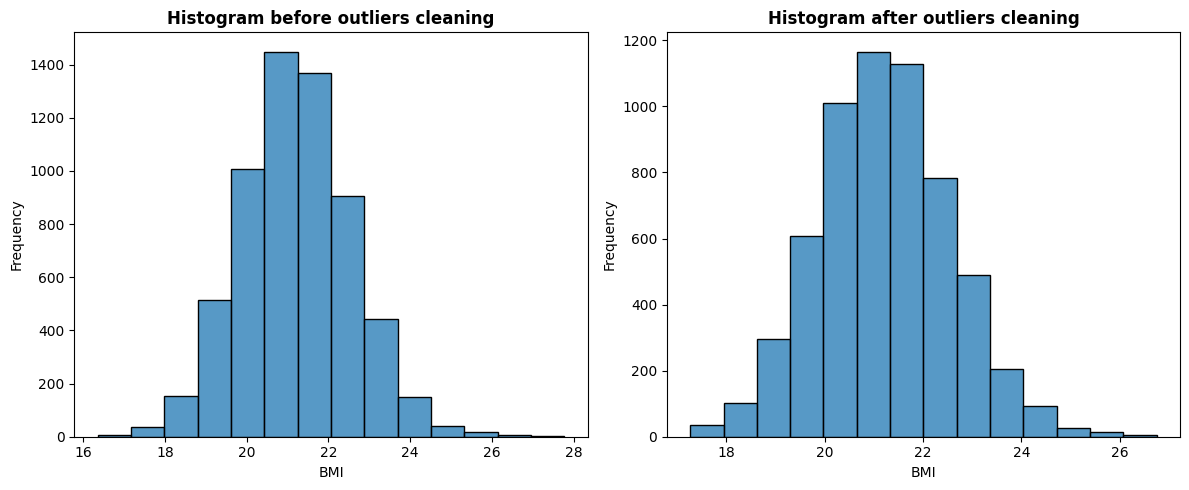

In [631]:
compare_distributions(numeric_cyclists_df, cleaned_cyclists_df, "BMI")

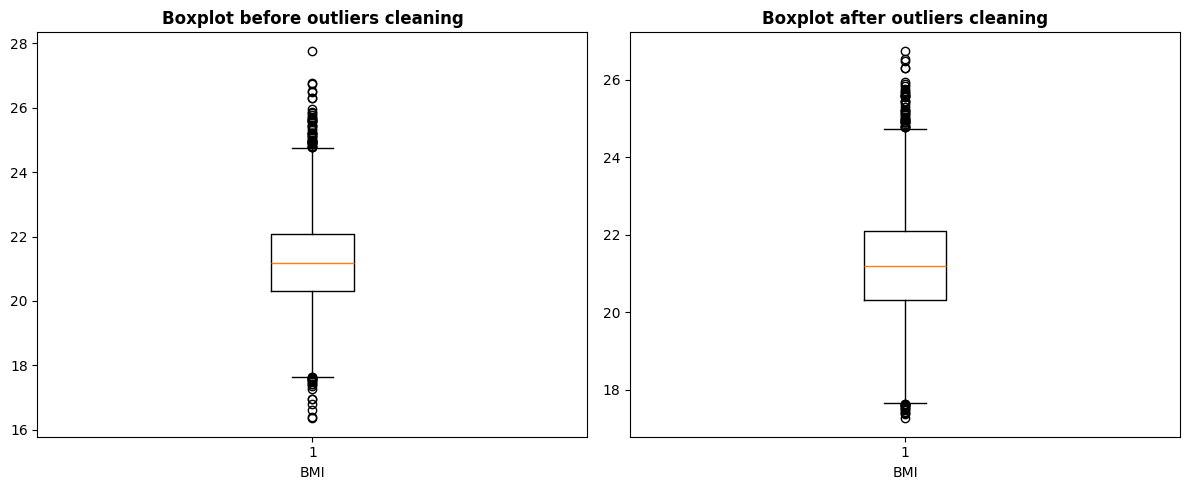

In [632]:
compare_box_plots(numeric_cyclists_df,cleaned_cyclists_df, "BMI")

#### std_dev position (17): complete outliers removal

In [633]:
outliers_removal_obj = outliers_removal(numeric_cyclists_df, "std_dev position", cleaned_cyclists_df)
lower_bound_stdPos = outliers_removal_obj['lower_bound']
upper_bound_stdPos = outliers_removal_obj['upper_bound']   
res_cleaned_df = outliers_removal_obj['cleaned_df']


Remaining rows after removal: 5948
Removed rows: 17


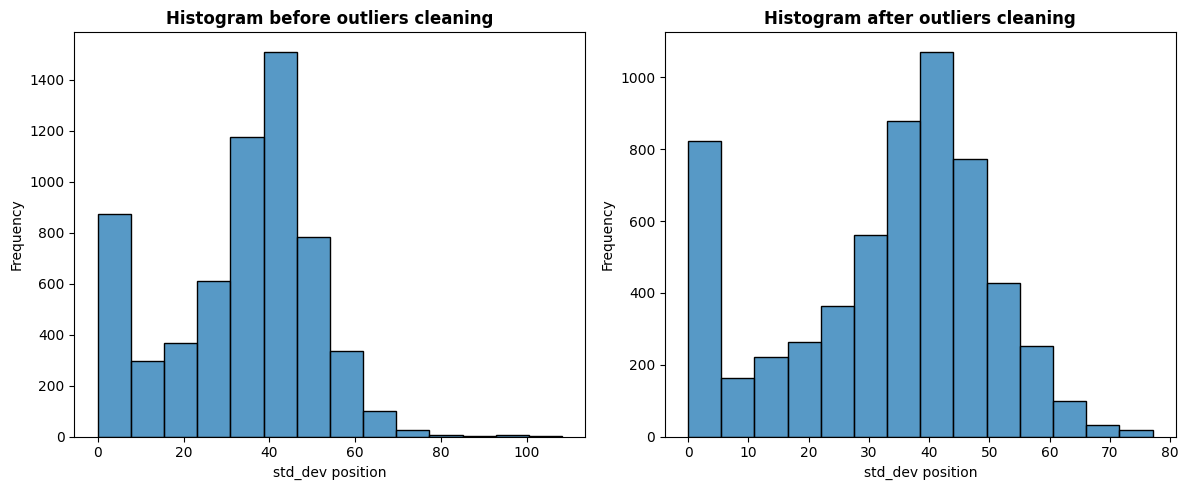

In [634]:
compare_distributions(numeric_cyclists_df, res_cleaned_df, "std_dev position")

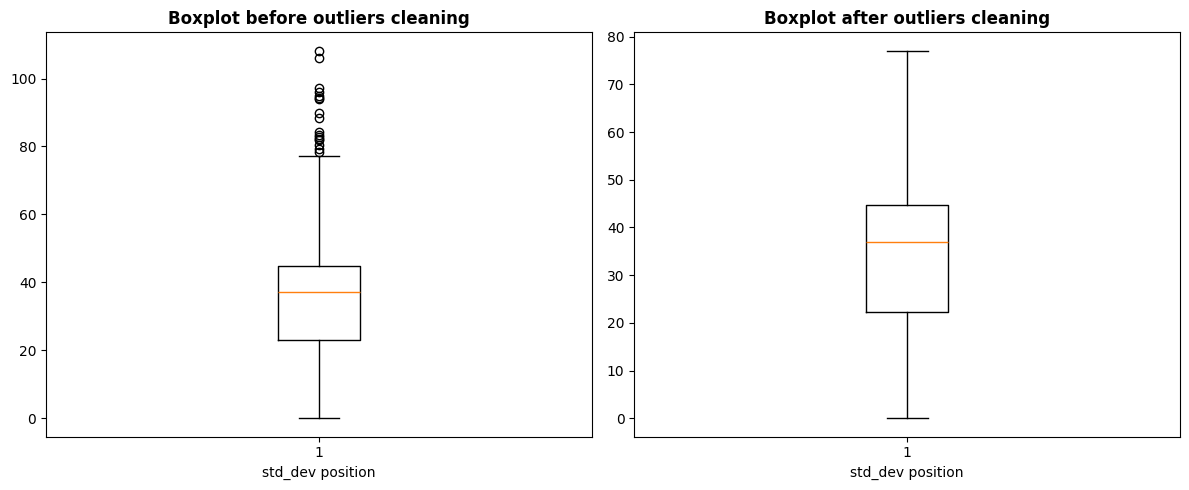

In [635]:
compare_box_plots(numeric_cyclists_df, res_cleaned_df, "std_dev position")

#### std_dev position (17): extreme outliers removal

In [636]:
column = "std_dev position"
outliers = numeric_cyclists_df[
    (numeric_cyclists_df[column] < lower_bound_stdPos) | (numeric_cyclists_df[column] > upper_bound_stdPos)
]

outliers_above = outliers[outliers[column] > upper_bound_stdPos]
outliers_below = outliers[outliers[column] < lower_bound_stdPos]

print(f"Outliers above upper bound ({upper_bound_stdPos}): {len(outliers_above)}")
print(f"Outliers below lower bound ({lower_bound_stdPos}): {len(outliers_below)}")
print(f"Total outliers: {len(outliers_above) + len(outliers_below)}")


column_outliers_df = pd.DataFrame({
    "Name": outliers['name'],
    "Column": column,
    "Lower Bound": lower_bound_stdPos,
    "Upper Bound": upper_bound_stdPos,
    "Outlier Value": outliers[column].round(2)
})

range_1 = upper_bound_stdPos + 5
range_2 = range_1 + 5
range_3 = range_2 + 5
range_4 = range_3 + 5
range_5 = range_4 + 5
range_6 = range_4 + 5

outliers_range_1 = column_outliers_df[column_outliers_df['Outlier Value'] < range_1 ]
outliers_range_2 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_1) & (column_outliers_df['Outlier Value'] < range_2)]
outliers_range_3 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_2) & (column_outliers_df['Outlier Value'] < range_3)]
outliers_range_4 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_3) & (column_outliers_df['Outlier Value'] < range_4)]
outliers_range_5 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_4) & (column_outliers_df['Outlier Value'] < range_5)]
outliers_range_6 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_5) & (column_outliers_df['Outlier Value'] < range_6)]
outliers_range_7 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_6)]


print(f"Number of outliers in the range of [{upper_bound_stdPos}, {range_1}]:{len(outliers_range_1)}")
print(f"Number of outliers in the range of [{range_1}, {range_2}]:{len(outliers_range_2)}")
print(f"Number of outliers in the range of [{range_2}, {range_3}]:{len(outliers_range_3)}")
print(f"Number of outliers in the range of [{range_3}, {range_4}]:{len(outliers_range_4)}")
print(f"Number of outliers in the range of [{range_4}, {range_5}]:{len(outliers_range_5)}")
print(f"Number of outliers in the range of [{range_5}, {range_6}]:{len(outliers_range_6)}")
print(f"Number of outliers > {range_6}:{len(outliers_range_7)}")



Outliers above upper bound (77.56711891904379): 17
Outliers below lower bound (0.0): 0
Total outliers: 17
Number of outliers in the range of [77.56711891904379, 82.56711891904379]:5
Number of outliers in the range of [82.56711891904379, 87.56711891904379]:3
Number of outliers in the range of [87.56711891904379, 92.56711891904379]:2
Number of outliers in the range of [92.56711891904379, 97.56711891904379]:5
Number of outliers in the range of [97.56711891904379, 102.56711891904379]:0
Number of outliers in the range of [102.56711891904379, 102.56711891904379]:0
Number of outliers > 102.56711891904379:2


Let’s consider ‘extreme’ outliers as those above approximately 97.56, so the two most extreme ones. These thresholds correspond to the 99.97nd percentile.

In [637]:
Q4 = numeric_cyclists_df["std_dev position"].quantile(0.9997)
Q4

np.float64(98.78490386428663)

In [638]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[(cleaned_cyclists_df['std_dev position'] <= Q4)]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")

Remaining rows after removal: 5963
Removed rows: 2


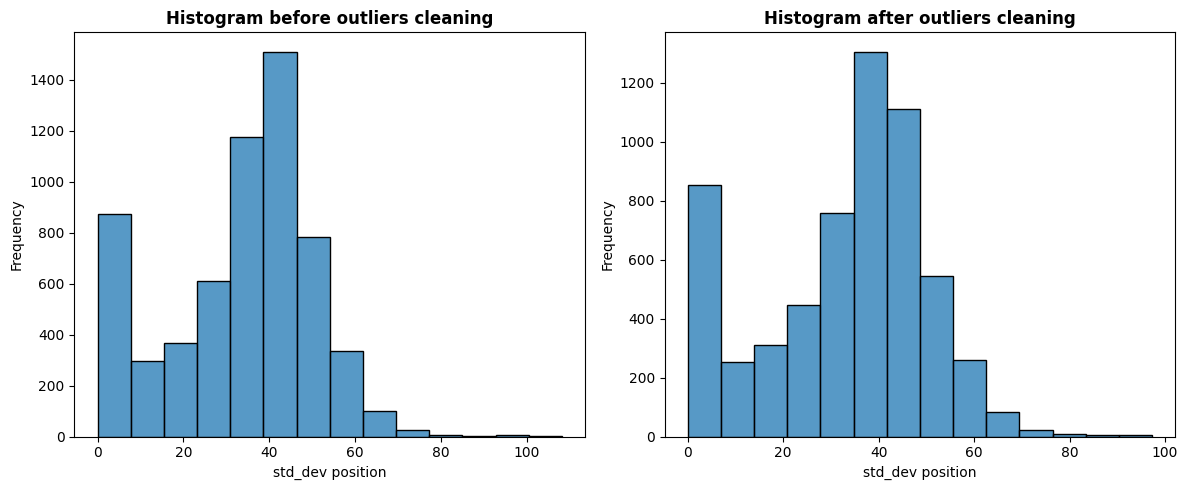

In [639]:
compare_distributions(numeric_cyclists_df, cleaned_cyclists_df, "std_dev position", )

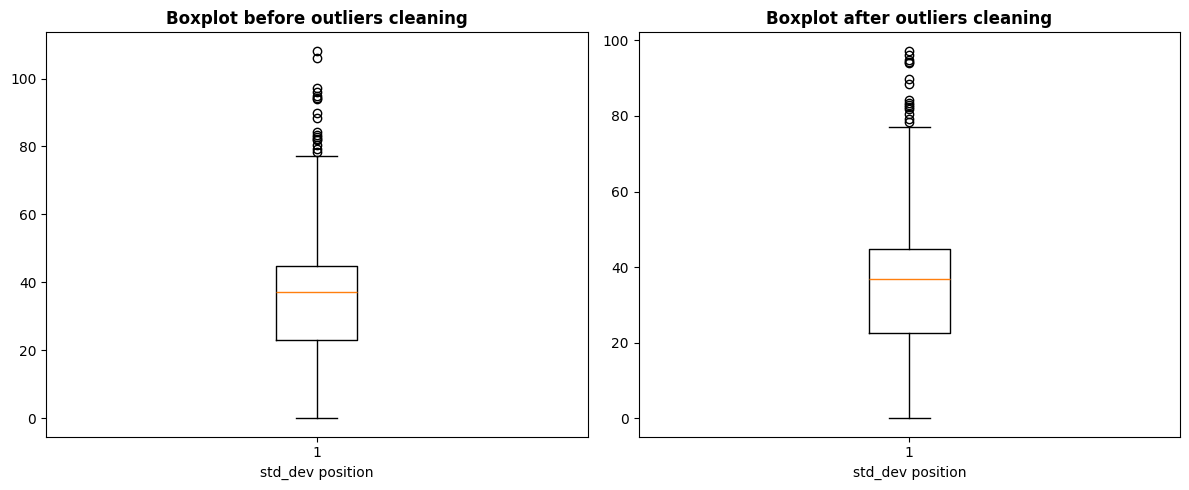

In [640]:
compare_box_plots(numeric_cyclists_df, cleaned_cyclists_df, "std_dev position",)

#### median position (8): complete outliers removal

In [641]:
outliers_removal_obj = outliers_removal(numeric_cyclists_df, "median position", cleaned_cyclists_df)
lower_bound_medianPos = outliers_removal_obj['lower_bound']
upper_bound_medianPos = outliers_removal_obj['upper_bound']   
res_cleaned_df = outliers_removal_obj['cleaned_df']


Remaining rows after removal: 5955
Removed rows: 8


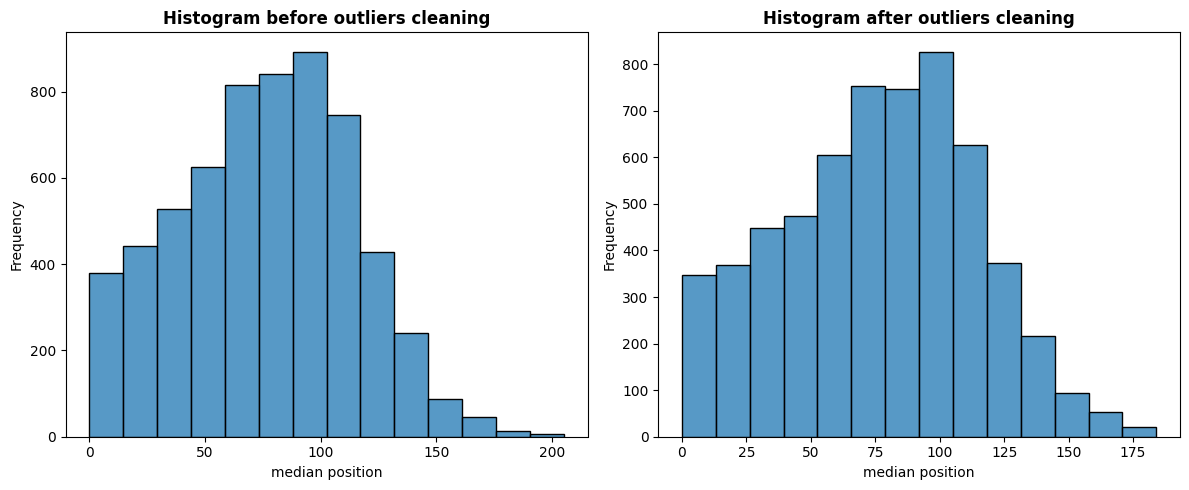

In [642]:
compare_distributions(numeric_cyclists_df, res_cleaned_df, "median position")

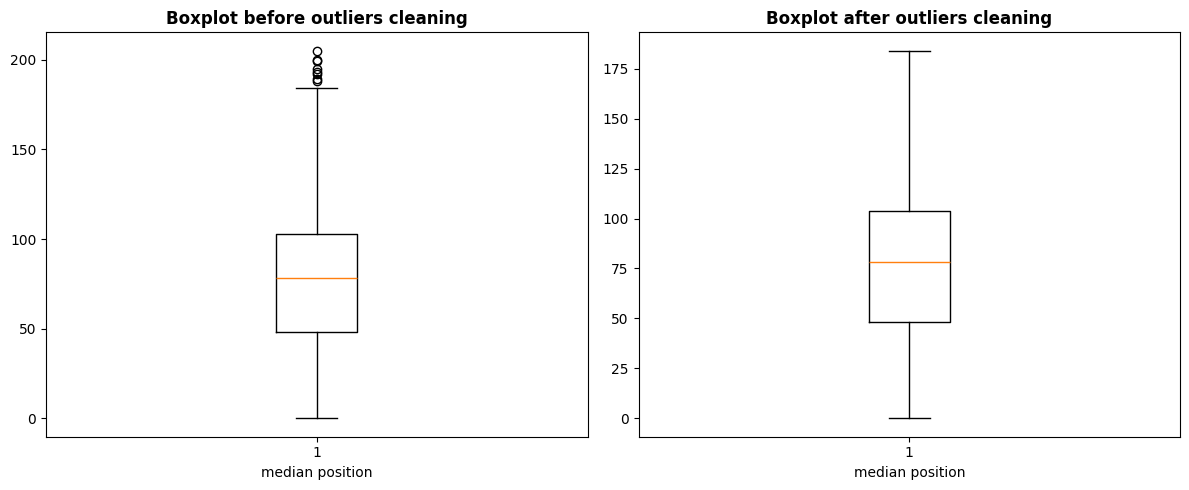

In [643]:
compare_box_plots(numeric_cyclists_df, res_cleaned_df, "median position")

In [644]:
print(lower_bound_medianPos)
print(upper_bound_medianPos)

0
185.5


#### median position (8): extreme outliers removal

In [645]:
column = "median position"
outliers = numeric_cyclists_df[
    (numeric_cyclists_df[column] < lower_bound_medianPos) | (numeric_cyclists_df[column] > upper_bound_medianPos)
]

outliers_above = outliers[outliers[column] > upper_bound_medianPos]
outliers_below = outliers[outliers[column] < lower_bound_medianPos]

print(f"Outliers above upper bound ({upper_bound_medianPos}): {len(outliers_above)}")
print(f"Outliers below lower bound ({lower_bound_medianPos}): {len(outliers_below)}")
print(f"Total outliers: {len(outliers_above) + len(outliers_below)}")


column_outliers_df = pd.DataFrame({
    "Name": outliers['name'],
    "Column": column,
    "Lower Bound": lower_bound_medianPos,
    "Upper Bound": upper_bound_medianPos,
    "Outlier Value": outliers[column].round(2)
})

range_1 = upper_bound_medianPos + 5
range_2 = range_1 + 5
range_3 = range_2 + 5
range_4 = range_3 + 5
range_5 = range_4 + 5
range_6 = range_4 + 5

outliers_range_1 = column_outliers_df[column_outliers_df['Outlier Value'] < range_1 ]
outliers_range_2 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_1) & (column_outliers_df['Outlier Value'] < range_2)]
outliers_range_3 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_2) & (column_outliers_df['Outlier Value'] < range_3)]
outliers_range_4 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_3) & (column_outliers_df['Outlier Value'] < range_4)]
outliers_range_5 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_4) & (column_outliers_df['Outlier Value'] < range_5)]
outliers_range_6 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_5) & (column_outliers_df['Outlier Value'] < range_6)]
outliers_range_7 = column_outliers_df[(column_outliers_df['Outlier Value'] >= range_6)]


print(f"Number of outliers in the range of [{upper_bound_medianPos}, {range_1}]:{len(outliers_range_1)}")
print(f"Number of outliers in the range of [{range_1}, {range_2}]:{len(outliers_range_2)}")
print(f"Number of outliers in the range of [{range_2}, {range_3}]:{len(outliers_range_3)}")
print(f"Number of outliers in the range of [{range_3}, {range_4}]:{len(outliers_range_4)}")
print(f"Number of outliers in the range of [{range_4}, {range_5}]:{len(outliers_range_5)}")
print(f"Number of outliers in the range of [{range_5}, {range_6}]:{len(outliers_range_6)}")
print(f"Number of outliers > {range_6}:{len(outliers_range_7)}")



Outliers above upper bound (185.5): 8
Outliers below lower bound (0): 0
Total outliers: 8
Number of outliers in the range of [185.5, 190.5]:2
Number of outliers in the range of [190.5, 195.5]:3
Number of outliers in the range of [195.5, 200.5]:2
Number of outliers in the range of [200.5, 205.5]:1
Number of outliers in the range of [205.5, 210.5]:0
Number of outliers in the range of [210.5, 210.5]:0
Number of outliers > 210.5:0


Given that there are no outliers that can be considered much more extreme than others, and that the distribution does not vary much by eliminating them all, we proceed to eliminate all the outliers for _median position_

In [646]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[
        (cleaned_cyclists_df["median position"] >= lower_bound_medianPos) & (cleaned_cyclists_df[column] <= upper_bound_medianPos)
    ]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")

Remaining rows after removal: 5955
Removed rows: 8


## Data normalization

In [647]:
from sklearn.preprocessing import StandardScaler

def standardize_fun(df):
    scaler = StandardScaler()
    scaler.fit(df)
    X = scaler.transform(df)
    standardized_df = pd.DataFrame(X, columns=df.columns, index=df.index)
    print(standardized_df)
    
    standardizer = {"scaler": scaler, "standardized_df": standardized_df}

    return standardizer
   


# COMMENTARE O DECOMMENTARE LA RIGA SOTTO PER ESEGUIRE IL KMEANS SUL DATAFRAME SENZA PULIZIA (ATTUALMENTE SOLO SU # CYCLIST RACES) 

In [648]:

numeric_cyclists_df = cleaned_cyclists_df # -->> commentare questa riga se si vuole il clustering sul dataframe pre cleaning da outliers
len(numeric_cyclists_df)

5955

In [649]:
numeric_cyclists_df = numeric_cyclists_df.drop("name", axis=1)

standardizer = standardize_fun(numeric_cyclists_df)
standardized_cyclists_df = standardizer['standardized_df']

           BMI  median position  # cyclist races  birth_year  std_dev position
1    -0.933289        -1.016874         1.563687   -1.462154          0.799777
2     1.167189        -0.910558         0.507560   -1.270509         -0.009832
3     1.386820        -1.814251        -0.320444   -1.653798         -0.739312
4     0.061673        -1.362404         0.499111   -1.462154         -0.369439
5    -0.222643        -1.840830        -0.202158   -1.653798          0.118844
...        ...              ...              ...         ...               ...
6090 -1.127846         2.571318        -0.717548   -0.312285         -1.852516
6091 -0.879180        -1.575038        -0.717548   -0.567811         -1.852516
6092  3.140796        -0.591607        -0.717548    1.156992         -1.852516
6093 -0.894239        -1.016874        -0.717548   -1.653798         -1.852516
6094  1.493976        -0.405553        -0.717548   -1.398272         -1.852516

[5955 rows x 5 columns]


## PCA
We apply Principal Component Analysis (PCA) to the standardized dataset (standardized_cyclists_df) to reduce its dimensionality while preserving 90% of the variance. It calculates the number of principal components required to achieve this variance threshold and transforms the dataset into the PCA-reduced space

In [650]:
# Try to apply PCA to get the optimal number of components
pca_instance = PCA(n_components=0.90)  # Preserve 90% of the variance
pca_std_numeric_cyclists = pca_instance.fit_transform(standardized_cyclists_df)

print(f"# selected principal components: {pca_instance.n_components_}")

# selected principal components: 4


In [651]:
# pca = PCA()
# pca.fit(X) 

# # Compute the contribution (loadings) of each feature to each principal component
# loadings = pd.DataFrame(
#     pca.components_.T, # Transpose to align features with components
#     columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Label columns as PC1, PC2, etc.
#     index=numeric_cyclists_df.columns # Use feature names as index
# )

# display(loadings)

# # Calculate the importance of each feature based on the first two principal components
# top_components = loadings.iloc[:, :2].abs().sum(axis=1) 
# top_variables = top_components.sort_values(ascending=False)


# print("\nFeatures sorted by contribution:")
# print(top_variables)


# selected_columns = top_variables.index.tolist()
# print(f"\nSelected columns: {selected_columns}")


In [652]:
pca_std_numeric_cyclists

array([[-0.34956381,  2.03816271, -1.40192112,  0.73325803],
       [-1.11512137,  1.48753928,  0.75144621, -0.01285046],
       [-2.48880771,  1.23476398,  0.88103493, -0.1422566 ],
       ...,
       [-1.0773674 , -0.43653015,  2.66131075, -2.48289351],
       [-2.6380196 , -0.48055358, -0.95833783,  0.02827371],
       [-2.33549507, -0.16649217,  1.38075703, -0.66367382]])

## Kmeans grid search

In [653]:
def kmeans_grid_search(df):
    results = []  # used to save sse and silhouette for each k
    previous_sse = None

    for k in range(2,16):
        kmeans = KMeans(n_clusters=k, max_iter=300, random_state=42)
        labels = kmeans.fit_predict(df)
        sse = kmeans.inertia_  # Calcola il SSE
        silhouette_avg = silhouette_score(df, labels) 

        if previous_sse is not None:
            sse_reduction_percentage = ((previous_sse - sse) / previous_sse) * 100
            print(f"k: {k} -> silhouette: {silhouette_avg}, sse: {sse}, sse reduction: {sse_reduction_percentage:.2f}%")
        else:
            print(f"k: {k} -> silhouette: {silhouette_avg}, sse: {sse}")
    
        # Salva i risultati
        results.append({"k": k, "sse": sse, "silhouette": silhouette_avg})
        previous_sse = sse
   
    return results

In [654]:
def k_means_evaluation_plotting(results):

    print(results)
    k_values = [result["k"] for result in results]
    sse_values = [result["sse"] for result in results]
    silhouette_values = [result["silhouette"] for result in results]

    plt.figure()
    plt.plot(k_values, sse_values, marker='o', label='SSE')
    plt.title('SSE with Elbow method')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('SSE')
    plt.show()

    plt.figure()
    plt.plot(k_values, silhouette_values, marker='o', label='Silhouette Score', color='orange')
    plt.title('Silhouette Score')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.show()

In [655]:
def get_best_k(results):
    best_result = max(results, key=lambda x: x["silhouette"])

    best_k = best_result["k"]
    return best_k

In [656]:
# # Configurazione dei parametri per il Grid Search
# k_values = range(2, 11)
# param_grid = {
#     'n_clusters': k_values,
# }

# # Creazione del modello KMeans
# kmeans = KMeans(random_state=42)

# # Variabili per tracciare i migliori risultati
# best_combined_score = -float('inf')
# best_combined_params = {}

# # Liste per normalizzazione
# sse_all = []
# silhouette_all = []
# separation_all = []
# param_list = []

# # Itera sui parametri
# for n_clusters in param_grid['n_clusters']:

#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, init='k-means++', max_iter=300)
    
#     labels = kmeans.fit_predict(X)
#     silhouette = silhouette_score(X, labels)
#     sse = kmeans.inertia_
#     separation = davies_bouldin_score(X, labels)

#     # Aggiungi ai valori globali per normalizzare successivamente
#     sse_all.append(sse)
#     silhouette_all.append(silhouette)
#     separation_all.append(separation)
#     param_list.append({'n_clusters': n_clusters, 'max_iter': 300})  # Salva i parametri associati

#     print(f"n_clusters: {n_clusters}, max_iter: {300} -> SSE: {sse}, Davies-Bouldin: {separation}, Silhouette: {silhouette}")

# # Normalizza le metriche
# sse_min, sse_max = min(sse_all), max(sse_all)
# silhouette_min, silhouette_max = min(silhouette_all), max(silhouette_all)
# separation_min, separation_max = min(separation_all), max(separation_all)

# sse_norm = [(sse_max - sse) / (sse_max - sse_min) for sse in sse_all]
# silhouette_norm = [(silhouette - silhouette_min) / (silhouette_max - silhouette_min) for silhouette in silhouette_all]
# separation_norm = [(separation_max - sep) / (separation_max - separation_min) for sep in separation_all]

# # Ricalcola il punteggio combinato
# for i, (sse, silhouette, separation) in enumerate(zip(sse_norm, silhouette_norm, separation_norm)):
#     combined_score = (silhouette + sse + separation) / 3  # Media pesata
#     if combined_score > best_combined_score:
#         best_combined_score = combined_score
#         best_combined_params = {'n_clusters': param_list[i]['n_clusters'],
#             'max_iter': param_list[i]['max_iter'],'index': i, 'sse': sse, 'silhouette': silhouette, 'separation': separation}

# # Risultati
# print("\nMiglior punteggio combinato:", best_combined_score)
# print("Parametri associati:", best_combined_params)

In [657]:
# # Crea il grafico della distribuzione dei punti nei cluster (scatter plot)
# plt.figure(figsize=(10, 6))
# sbn.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="Set2", s=50, alpha=0.7)
# plt.title(f'Cluster con {best_params["n_clusters"]} cluster', fontsize=14)
# plt.xlabel('Feature 1', fontsize=12)
# plt.ylabel('Feature 2', fontsize=12)
# plt.show()

# # Calcola la silhouette score per ogni punto
# silhouette_vals = silhouette_samples(X, labels)

# # Crea un grafico della silhouette score per ogni punto
# plt.figure(figsize=(10, 6))
# sbn.histplot(silhouette_vals, kde=True, color="skyblue", bins=50)
# plt.title(f'Punteggio Silhouette per {best_params["n_clusters"]} cluster', fontsize=14)
# plt.xlabel('Silhouette Score', fontsize=12)
# plt.ylabel('Frequenza', fontsize=12)
# plt.show()

In [658]:
results = kmeans_grid_search(pca_std_numeric_cyclists)

k: 2 -> silhouette: 0.28373491063688666, sse: 19671.281643791226
k: 3 -> silhouette: 0.28171711397061683, sse: 15412.846817790329, sse reduction: 21.65%
k: 4 -> silhouette: 0.2575038975139409, sse: 12985.707608973265, sse reduction: 15.75%
k: 5 -> silhouette: 0.24975695940082465, sse: 11481.251524697247, sse reduction: 11.59%
k: 6 -> silhouette: 0.24520918814214154, sse: 10178.105161536558, sse reduction: 11.35%
k: 7 -> silhouette: 0.23283130213025152, sse: 9639.23536857188, sse reduction: 5.29%
k: 8 -> silhouette: 0.22940309632612146, sse: 8721.967865673694, sse reduction: 9.52%
k: 9 -> silhouette: 0.2198671794721879, sse: 8259.7484180007, sse reduction: 5.30%
k: 10 -> silhouette: 0.21213322568669402, sse: 7813.744566831493, sse reduction: 5.40%
k: 11 -> silhouette: 0.20874630143706527, sse: 7427.345731018795, sse reduction: 4.95%
k: 12 -> silhouette: 0.20887244021381512, sse: 7086.4572803550345, sse reduction: 4.59%
k: 13 -> silhouette: 0.19875614609643127, sse: 6898.823525563201, ss

[{'k': 2, 'sse': 19671.281643791226, 'silhouette': np.float64(0.28373491063688666)}, {'k': 3, 'sse': 15412.846817790329, 'silhouette': np.float64(0.28171711397061683)}, {'k': 4, 'sse': 12985.707608973265, 'silhouette': np.float64(0.2575038975139409)}, {'k': 5, 'sse': 11481.251524697247, 'silhouette': np.float64(0.24975695940082465)}, {'k': 6, 'sse': 10178.105161536558, 'silhouette': np.float64(0.24520918814214154)}, {'k': 7, 'sse': 9639.23536857188, 'silhouette': np.float64(0.23283130213025152)}, {'k': 8, 'sse': 8721.967865673694, 'silhouette': np.float64(0.22940309632612146)}, {'k': 9, 'sse': 8259.7484180007, 'silhouette': np.float64(0.2198671794721879)}, {'k': 10, 'sse': 7813.744566831493, 'silhouette': np.float64(0.21213322568669402)}, {'k': 11, 'sse': 7427.345731018795, 'silhouette': np.float64(0.20874630143706527)}, {'k': 12, 'sse': 7086.4572803550345, 'silhouette': np.float64(0.20887244021381512)}, {'k': 13, 'sse': 6898.823525563201, 'silhouette': np.float64(0.19875614609643127)}

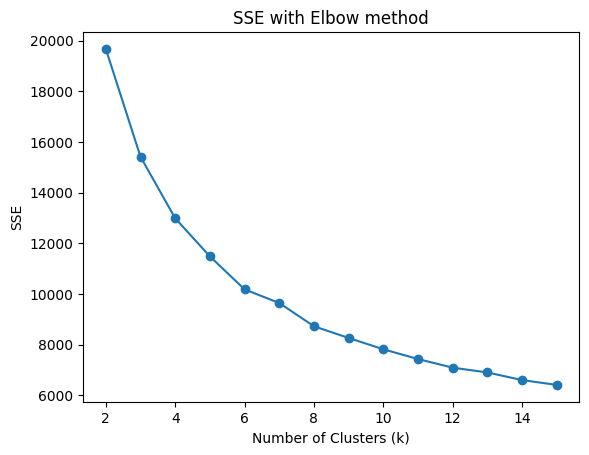

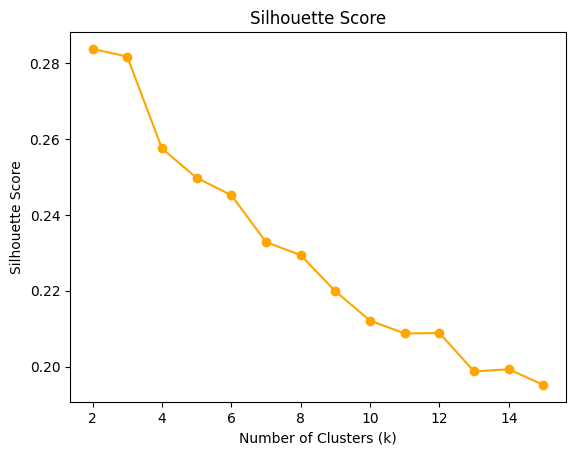

In [659]:
k_means_evaluation_plotting(results)

## Compute Kmeans algorithm with best K found
Analyzing the Elbow Method of SSE and the Silhouette Score, the optimal  k  values do not align. The Silhouette Score suggests  k = 2  as the optimal number of clusters, while the SSE indicates  k = 5  or  k = 6 . As a trade-off, we choose  k = 4 .

In [660]:
def kmeans_run(data, best_k, scaler):
    scaler = standardizer['scaler']
    print(f"\nBest k based on a trade-off between silhuoette score and sse: {best_k}")

    # best kmeans with best clusters number
    best_kmeans = KMeans(n_clusters=best_k, random_state=42, init='k-means++', max_iter=300)

    best_kmeans.fit(data)
    print(f"k: {best_k}, Number of iterations: {best_kmeans.n_iter_}")

    centers = best_kmeans.cluster_centers_

    # Trasforma i centroidi dallo spazio PCA a quello standardizzato
    centers_standardized = pca_instance.inverse_transform(centers)

    # Inverso della trasformazione per ottenere i centroidi nello spazio originale (non normalizzato)
    centers_original_space = scaler.inverse_transform(centers_standardized)

    print("Centroids")
    print(centers_original_space)

    kmeans_data = {"best_kmeans": best_kmeans, "centroids": centers_original_space}

    return kmeans_data

  



In [661]:
kmeans_data = kmeans_run(data=pca_std_numeric_cyclists, best_k=4, scaler=standardizer['scaler'])
best_kmeans = kmeans_data['best_kmeans']
centroids = kmeans_data['centroids']


Best k based on a trade-off between silhuoette score and sse: 4
k: 4, Number of iterations: 11
Centroids
[[  20.94884911   59.91241468  294.29959499 1981.22013319   44.32571579]
 [  20.54260068  102.91353931   38.93422771 1986.01942209   28.66011261]
 [  22.05016545   91.47887253   74.81567317 1971.28352836   46.24838042]
 [  21.31245481   35.01335444   17.16481658 1956.05627055   14.7625842 ]]


In [662]:
# count points for each cluster
cluster_counts = pd.Series(best_kmeans.labels_).value_counts().sort_index()

print("Number of points for each cluster")
print(cluster_counts)

Number of points for each cluster
0     984
1    1873
2    1664
3    1434
Name: count, dtype: int64


Let's print a summary of the average values for each feature within the clusters

In [663]:
numeric_cyclists_df = numeric_cyclists_df.copy() 
# Add Cluster as a column to the dataset
numeric_cyclists_df['Cluster'] = best_kmeans.labels_

# Compute statistics for each feature grouped by cluster
detailed_cluster_stats = numeric_cyclists_df.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])

detailed_cluster_stats.columns = ['_'.join(col) for col in detailed_cluster_stats.columns]

display(detailed_cluster_stats)

,BMI_mean,BMI_median,BMI_min,BMI_max,median position_mean,median position_median,median position_min,median position_max,# cyclist races_mean,# cyclist races_median,# cyclist races_min,# cyclist races_max,birth_year_mean,birth_year_median,birth_year_min,birth_year_max,std_dev position_mean,std_dev position_median,std_dev position_min,std_dev position_max
Cluster,,,,,,,,,,,,,,,,,,,,
0,20.915235,20.900000,17.412666,25.310000,66.799797,67.0,8,131,308.294715,295.0,92,549,1978.840447,1979.0,1946.0,2000.0,42.622679,42.148645,18.713423,72.428232
1,20.548025,20.570000,17.263427,24.432154,101.155366,101.0,9,184,35.456487,17.0,1,220,1986.616658,1988.0,1951.0,2004.0,29.157312,33.270150,0.000000,65.760931
2,22.069447,22.040000,18.833727,26.750000,89.225962,90.0,4,178,70.152043,49.0,1,358,1972.079327,1971.0,1940.0,2002.0,46.725342,45.960965,0.000000,97.274526
3,21.308165,21.283847,17.486589,26.530000,35.182008,31.0,0,143,17.565551,4.0,1,267,1955.965132,1955.0,1933.0,1992.0,14.752854,13.034675,0.000000,58.149592


## Distribution of points for each feature across clusters

In [664]:
def clusters_box_plot(df):

    columns = [col for col in df.columns if col != 'Cluster']
    n_rows = (len(columns) + 2 - 1) // 2  

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows), sharey=False)

    # Rendi axes un array 1D per un accesso più semplice
    axes = axes.flatten()

    for i, column in enumerate(columns):
        sbn.boxplot(x='Cluster', y=column, data=df, ax=axes[i])
        axes[i].set_title(f"Distribution of '{column}'")
        axes[i].set_xlabel("Cluster")
        axes[i].set_ylabel(column)

    # Nascondi subplot extra (se presenti)
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

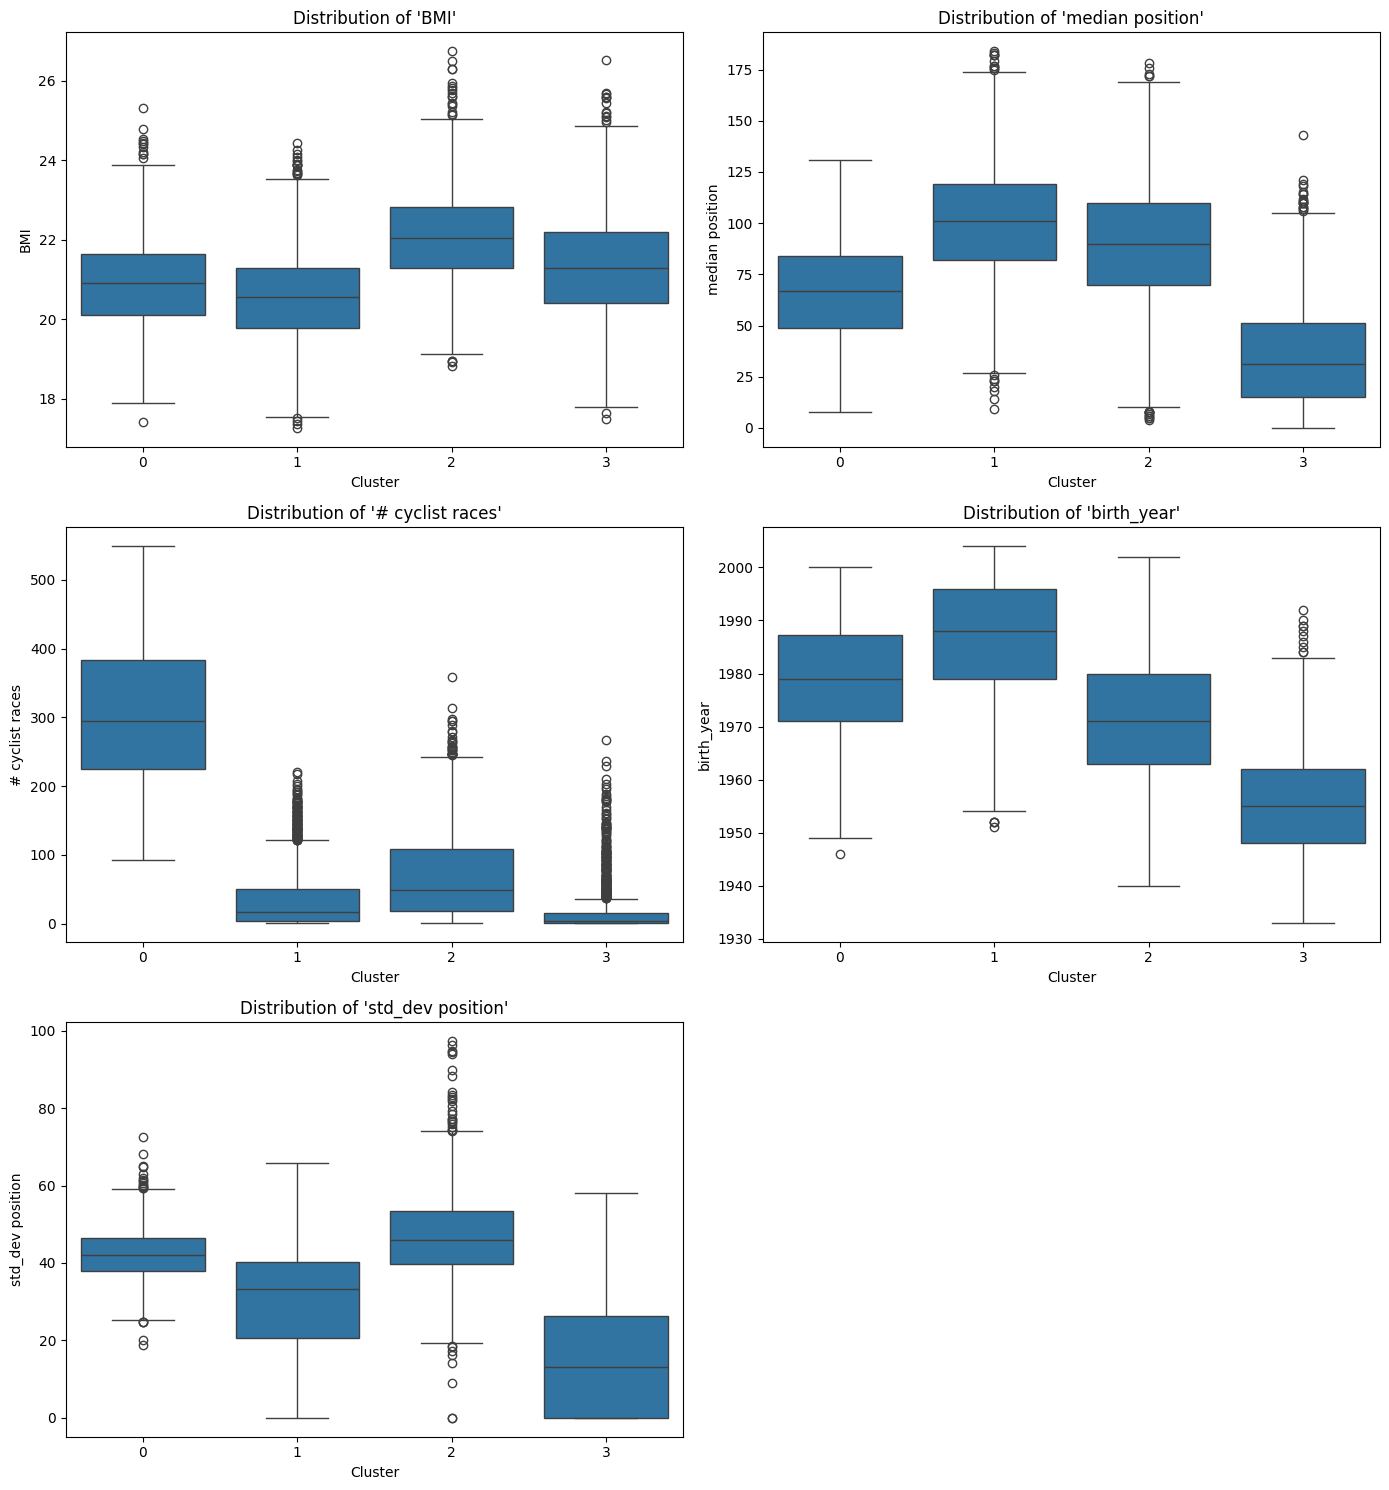

In [665]:
clusters_box_plot(numeric_cyclists_df)

### Box-plots analysis

By analying the box-plots above, we can try to analyze the 4 clusters by considering points distribution for each feature:
- **Cluster 0** (1798 points): 

  - **_BMI_**: values are centered around a median of 22, with a moderately tight interquartile range. There are some outliers on both the lower and upper ends, with the lowest BMI slightly below 18 and the highest around 28.
  
  - **_median position_**: this cluster has the widest IQR for the median position, with values ranging from ~20 to ~170. The median is approximately 80. There are many outliers: the gratest with ~200 and the lowest close to 0. 

  - **_cyclist races_**: cyclists in this cluster participated in not many races with a median below 100. There are some high-end outliers, with values over 300.
  
  - **_birth\_year_**: this cluster has a median birth year around 1970, with an IQR ranging from ~1965 to 1980. There are not outliers.

  - **_std\_dev position_**: the median standard deviation of position is around 42 and IQR ranges from 40 to ~58. This cluster has a lot of outliers on both the lower and the upper ends, from ~10 to above 100.

- **Cluster 1** (1913 points): 

  - **_BMI_**: the median BMI is approximately 21, and outliers are present on both ends.
  
  - **_median position_**: the median position is higher than the ones in the Cluster 0 (~100). Similar to Cluster 0, there are many high-end outliers close to 200, and many low-end outliers close to 20.

  - **_cyclist races_**: the distribution shows a tighter IQR and a lower median, below 50. There are high-end outliers, with values up to ~300.
  
  - **_birth\_year_**: the median birth year is ~1990. Outliers are present in the ~1950s.

  - **_std\_dev position_**: the median std deviation of position is around 37 and the IQR ranges from ~20 to ~40. There are not outliers.

- **Cluster 2** (899 points): 

  - **_BMI_**: the median BMI is around 21, similar to the Cluster 1, but here we don't have low-end outliers. Some high-end outliers exceed up to about 25.
  
  - **_median position_**: this cluster has a smaller IQR compared to the others, with a median position around ~60. It doesn't contains outliers.

  - **_cyclist races_**: this cluster has the highest median ~380 and a wide IQR. It also contains a significant number of high-end outliers, up to about ~1000.
  
  - **_birth\_year_**: here IQR is tighter compared to the others, ranging from ~1972 to ~1985 and a median value of 1980. There are no outliers.

  - **_std\_dev position_**: median is about ~40 and IQR is relatively and IQR is the narrowest compared to all the other clusters. Outliers appear to be on both the lower and the upper ends.

- **Cluster 3** (1485 points): 

  - **_BMI_**: median is about ~21 and the IQR is the slightly widest. There are few low-end outliers and many other high-end ones.
  
  - **_median position_**: the median position is the smallest here, about ~30, with some outliers on the upper end up to ~120.

  - **_cyclist races_**: cyclists in this cluster have the smallest number of races, with a median around ~10 and a tight IQR. There are a lot of outliers on the upper part, up to about ~380.
  
  - **_birth\_year_**: this cluster has the cyclists born in more distant years, with a median around 1955. Some outliers extend to earlier years, up to 1990s.

  - **_std\_dev position_**: this cluster has the smallest median standard deviation of position, ~18, but the widest IQR, ranging from ~0 to ~30, suggesting more consistency in performance. There are no outliers.




 

Based on the analysis provided, here’s what we can infer about the clusters:
#### Cluster 0
Cyclists appear to be a middle-ground group in many respects. They tend to have a median BMI around 22, which is higher than most other clusters, possibly indicating a group with a more average or heavier build. Their birth years cluster around the 1970s.

Their median race positions show the widest spread, ranging from poor to competitive positions, suggesting this cluster might include a mix of cyclists with varied abilities or those who perform differently depending on the type of race. While most cyclists in this cluster have participated in fewer than 100 races, there are a few individuals who are much more active, as indicated by the high-end outliers. This diversity suggests that Cluster 0 might represent an "intermediate" group with both experienced veterans and less competitive cyclists.

#### Cluster 1
Cluster 1 is defined by cyclists born in the 90s, and they generally have participated in relatively few races (median ~50). This could represent a group of cyclists who are earlier in their careers, or perhaps participating in fewer high-level races.

Their median position is relative higher (~100), indicating that they tend to finish races further back in the rankings. There are several high-end outliers in terms of race participation, which might indicate a subset of very active cyclists in this group.

The standard deviation of their race positions is lower than Cluster 0, suggesting slightly more consistent results. Overall, Cluster 1 might represent cyclists born later than those in cluster 0, developing cyclists, many of which are still finding their footing in the competitive field.

#### Cluster 2
Cluster 2 stands out as the most active and competitive group. These cyclists have participated in the highest number of races (median ~380). Their median birth year is around 1980.

This cluster shows a median position of ~60, indicating solid but not dominant performance in races. Cluster 2 demonstrates consistency in cyclists performance due to several key factors. Their median position is tightly distributed and their standard deviation of position is relatively low (~40), showing minimal fluctuations in their race outcomes. Also the group has participated in a large number of races while maintaining stable performance, suggesting experience and refined racing strategies.

There are also a significant number of outliers for race participation, suggesting a subset of overachievers who have raced in extraordinarily high numbers of events.

Cluster 2 likely represents a group of elite cyclists who are both highly competitive and active.

#### Cluster 3
Cyclists have the lowest participation in races, with a median of only ~10, but they display a very tight distribution in their performance, as seen by the smallest standard deviation (~18). Their consistent results and relatively low median position (~30) suggest they are experienced cyclists who focus on select events and excel in those. 

But it must be underlined that having participated in few competitions, these data are a bit "falsified".

These cyclists were born much earlier than those in the other clusters, with a median birth year around 1955 and some born as early as the 1930s. This cluster might include retired professionals or cyclists who continue to compete in races.

Cluster 3 likely represents "veterans" who prioritize quality over quantity in their racing careers.

## Clusters visualization with feature distributions and centroids 

In [666]:
    
def clusters_pairplot(df, centroids):
    pairplot = sbn.pairplot(
        df,
        hue='Cluster',
        palette='Set1',
        diag_kind='kde',
        markers='o',
        plot_kws={'alpha': 0.5}
    )

    for i, ax in enumerate(pairplot.axes.flat):
        # Get features for each subplot
        row_feature = pairplot.axes.flat[i].get_ylabel()
        col_feature = pairplot.axes.flat[i].get_xlabel()

        # Add centroids only to relevant scatter plots, excluding diagonal ones
        if row_feature in df.columns and col_feature in df.columns:
            ax.scatter(
                centroids[:, df.columns.get_loc(col_feature)],  
                centroids[:, df.columns.get_loc(row_feature)], 
                marker='x', s=100, c='black', label='Centroid'
            )

    plt.legend()
    plt.show()

In [667]:
numeric_cyclists_df.to_csv("../../df_cyclists_cluster.csv", index=False)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_53935/1658901490.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


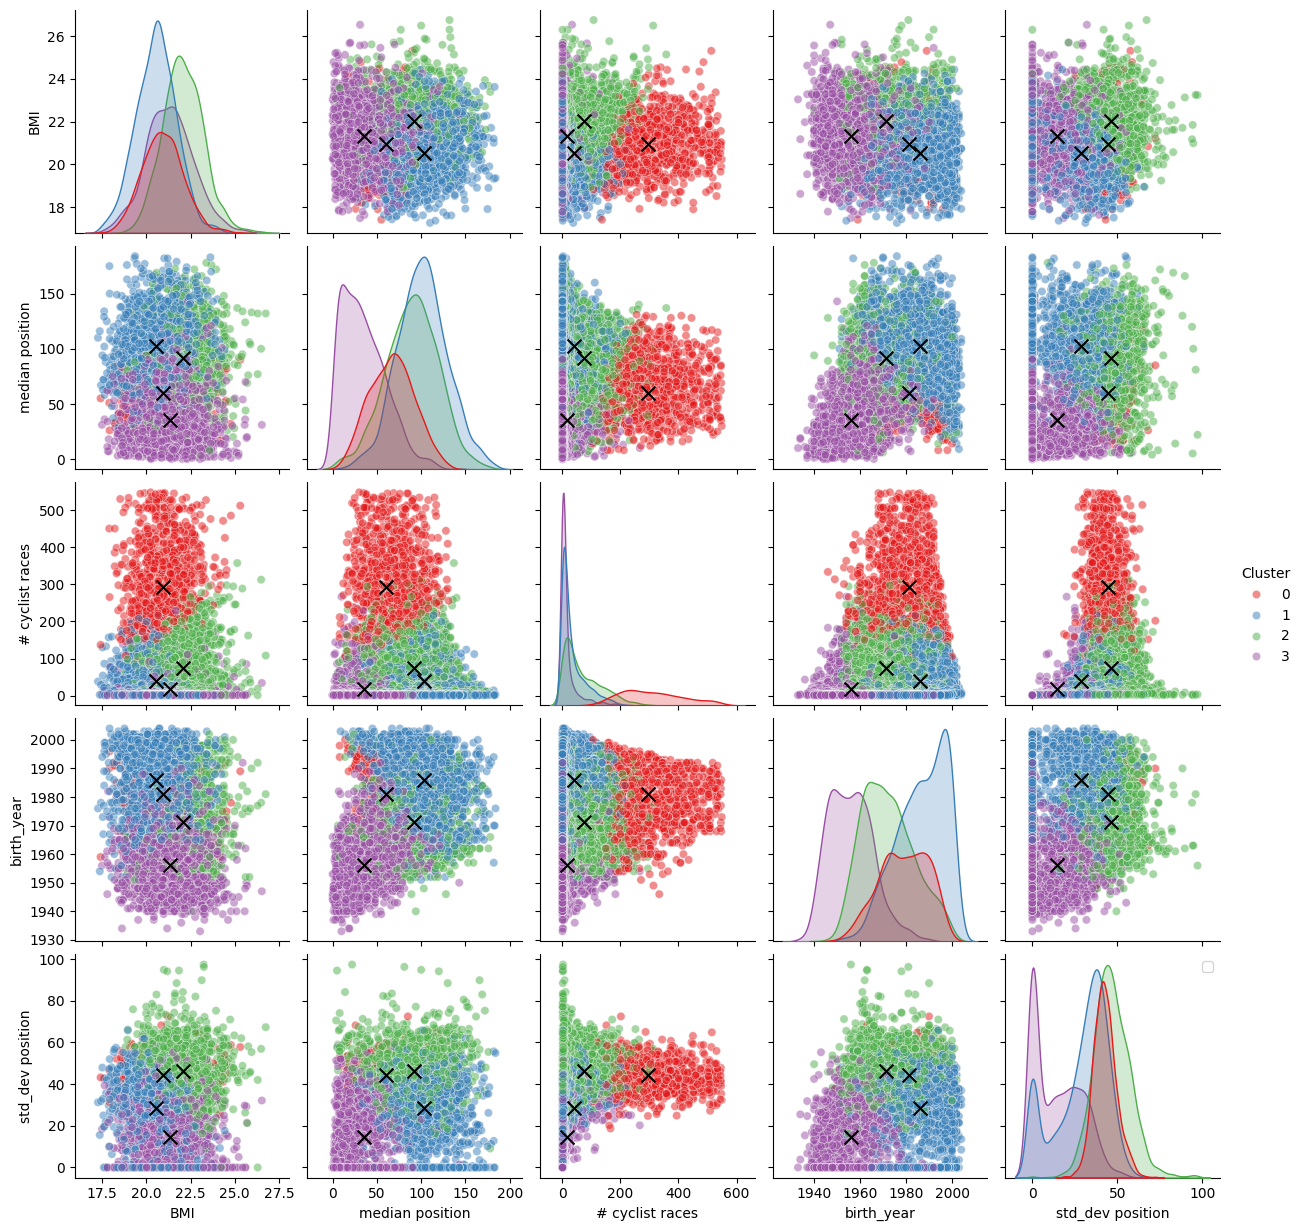

In [668]:
clusters_pairplot(numeric_cyclists_df, centroids)

### Pairplot analysis

By analyzing the paiplot above, we can try to analyze the 4 clusters and try to catch any relationships and patterns between the characteristics of the clusters that we were unable to catch with the box plots
- **Cluster 0**: 

  - **_std\_dev position_** vs **_BMI**: BMI values are slightly higher than the other clusters. Cyclists with more consistent performance (lower std_dev position) tend to have slightly higher BMI values and viceversa.
  
  - **_# cyclist races_** vs **_std\_dev position_**: as std_dev position increases, the number of races tends to decrease. It seems like that cyclists with higher variability in their performance tend to participate in fewer races.

  - **_# cyclist races_** vs **_median position_**: cyclists with better median positions, so lower values, tend to have higher race participation.

- **Cluster 1**: 

  - **_birth\_year_** vs **_median position_**: it seems like that there is a light relationship. Cyclists with worse rankings (higher median positions) tend to be earlier and viceversa.

  - **_median position_** vs **_# cyclist races_**: there is a weak relationship: cyclists with better performance (low median position) have partecipated in more races.
  
- **Cluster 2**: 

  -  **_birth\_year_** vs **_# cyclist races_**: cyclists born closer to 1990, tend to have participated in more races compared to those born earlier.
 
- **Cluster 3**: 
  
  - **_# cyclist races_** vs **_std\_dev position_**: cyclists with the lowest std_dev position participate in very few races. But this is probably due to the low total number of races in this cluster.
  

 



 

## Geographic distribution of cyclists across clusters
Here we analyzed the geographic distribution of cyclists across clusters by grouping them based on their geographic area and visualized the results. A bar chart was used to compare the counts of cyclists from different regions within each cluster. The chart highlights the relationships between geographic regions and cluster assignments, providing insights into how cyclists from various areas are distributed across the clusters.

In [669]:
cross_df = pandas.crosstab(best_kmeans.labels_, cyclists['geo area'])

cross_df.plot(kind='bar', stacked=False, 
                   title='relationship per cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

ValueError: Length of values (5955) does not match length of index (6095)

# Clustering for races

## Outliers Detection

In [ ]:
numerical_cols = races.select_dtypes(include=['float64', 'int64', 'Int64']).columns
numerical_cols

Index(['points', 'uci_points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'average_temperature', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'climb/length', 'median_delta', 'std_delta'],
      dtype='object')

In [ ]:
numeric_races_df = races[numerical_cols]
numeric_races_df

,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length,median_delta,std_delta
0,100,NaN,162000,1101,1.0,1241,NaN,1,0,0,0.006796,27.0,6.847590
1,80,100.0,196000,5575,5.0,821,NaN,1,0,0,0.028444,1957.0,873.835670
2,100,120.0,128000,781,1.0,1699,NaN,1,0,0,0.006102,29.0,44.079531
3,50,NaN,8100,68,NaN,804,NaN,1,0,0,0.008395,53.0,27.154498
4,100,120.0,192900,3743,3.0,1551,24.0,1,0,0,0.019404,1376.0,675.354230
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5276,80,100.0,148000,1441,1.0,881,NaN,1,0,0,0.009736,77.0,120.702086
5277,275,NaN,273000,2648,1.0,808,NaN,0,0,0,0.009700,270.0,327.665558
5278,50,NaN,185000,1726,NaN,779,NaN,1,0,0,0.009330,0.0,0.000000
5279,50,50.0,136400,1880,2.0,1045,NaN,1,0,0,0.013783,209.0,176.293335


In [ ]:
numeric_races_df.isna().sum()

points                    0
uci_points             3682
length                    0
climb_total               0
profile                2408
startlist_quality         0
average_temperature    5076
is_tarmac                 0
is_cobbled                0
is_gravel                 0
climb/length              0
median_delta              0
std_delta                 0
dtype: int64

In [ ]:
numeric_races_df = numeric_races_df.dropna(axis=1, how='any')
numeric_races_df.isna().sum()

points               0
length               0
climb_total          0
startlist_quality    0
is_tarmac            0
is_cobbled           0
is_gravel            0
climb/length         0
median_delta         0
std_delta            0
dtype: int64

In [ ]:
numeric_races_df = numeric_races_df[['points', 'climb/length', 'median_delta', 'std_delta', 'startlist_quality', 'climb_total', 'length']]
numeric_races_df

,points,climb/length,median_delta,std_delta,startlist_quality,climb_total,length
0,100,0.006796,27.0,6.847590,1241,1101,162000
1,80,0.028444,1957.0,873.835670,821,5575,196000
2,100,0.006102,29.0,44.079531,1699,781,128000
3,50,0.008395,53.0,27.154498,804,68,8100
4,100,0.019404,1376.0,675.354230,1551,3743,192900
...,...,...,...,...,...,...,...
5276,80,0.009736,77.0,120.702086,881,1441,148000
5277,275,0.009700,270.0,327.665558,808,2648,273000
5278,50,0.009330,0.0,0.000000,779,1726,185000
5279,50,0.013783,209.0,176.293335,1045,1880,136400


Check pearson correlation between these non-nan numeric features

,points,climb/length,median_delta,std_delta,startlist_quality,climb_total,length
points,1.000000,-0.064540,0.035331,0.051223,0.150270,0.222756,0.443516
climb/length,-0.064540,1.000000,0.191377,0.223502,0.015309,0.430213,-0.171295
median_delta,0.035331,0.191377,1.000000,0.793629,0.096597,0.303302,0.075307
std_delta,0.051223,0.223502,0.793629,1.000000,0.069962,0.301224,0.117848
startlist_quality,0.150270,0.015309,0.096597,0.069962,1.000000,0.095901,0.075864
climb_total,0.222756,0.430213,0.303302,0.301224,0.095901,1.000000,0.590508
length,0.443516,-0.171295,0.075307,0.117848,0.075864,0.590508,1.000000


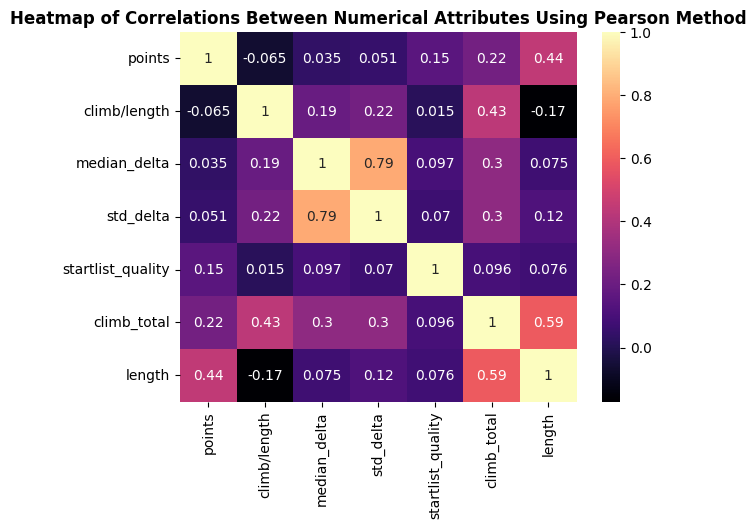

In [ ]:
pearson_matrix = numeric_races_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

Since _std\_delta_ and _median\_delta_ are highly correlated, we decide to drop _std\_delta_. Also _climb\_total_ and _length_ are moderately correlated.
Given that we already have the feature _climb/total_, we chose to drop _climb\_total_  while retaining _length_

In [ ]:
numeric_races_df = numeric_races_df.drop(['std_delta', 'climb_total'], axis=1)
numeric_races_df

,points,climb/length,median_delta,startlist_quality,length
0,100,0.006796,27.0,1241,162000
1,80,0.028444,1957.0,821,196000
2,100,0.006102,29.0,1699,128000
3,50,0.008395,53.0,804,8100
4,100,0.019404,1376.0,1551,192900
...,...,...,...,...,...
5276,80,0.009736,77.0,881,148000
5277,275,0.009700,270.0,808,273000
5278,50,0.009330,0.0,779,185000
5279,50,0.013783,209.0,1045,136400


In [ ]:
numeric_columns = numeric_races_df.columns
numeric_races_df = numeric_races_df.copy()
numeric_races_df['_url'] = races['_url']

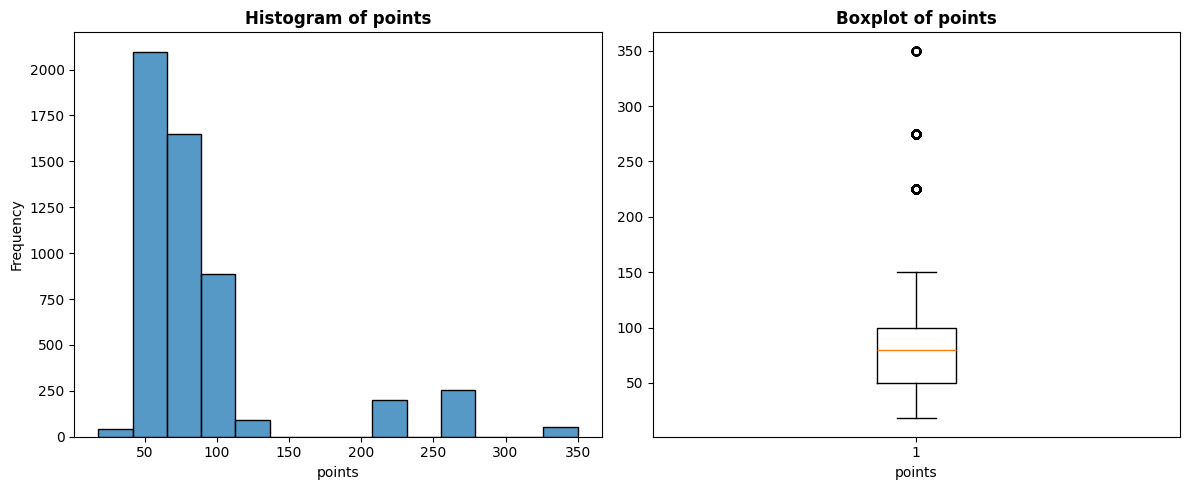

Outliers in points: [np.int64(225), np.int64(275), np.int64(350)]


,Url,Column,Lower Bound,Upper Bound,Outlier Value
13,ronde-van-vlaanderen/1980/result,points,18,175.0,275
15,milano-sanremo/2004/result,points,18,175.0,275
48,la-fleche-wallone/2015/result,points,18,175.0,225
69,liege-bastogne-liege/1999/result,points,18,175.0,275
74,paris-roubaix/2021/result,points,18,175.0,275
...,...,...,...,...,...
5244,milano-sanremo/1996/result,points,18,175.0,275
5248,amstel-gold-race/2013/result,points,18,175.0,225
5268,san-sebastian/2017/result,points,18,175.0,225
5269,gp-quebec/2010/result,points,18,175.0,225


Number of outliers in points: 510


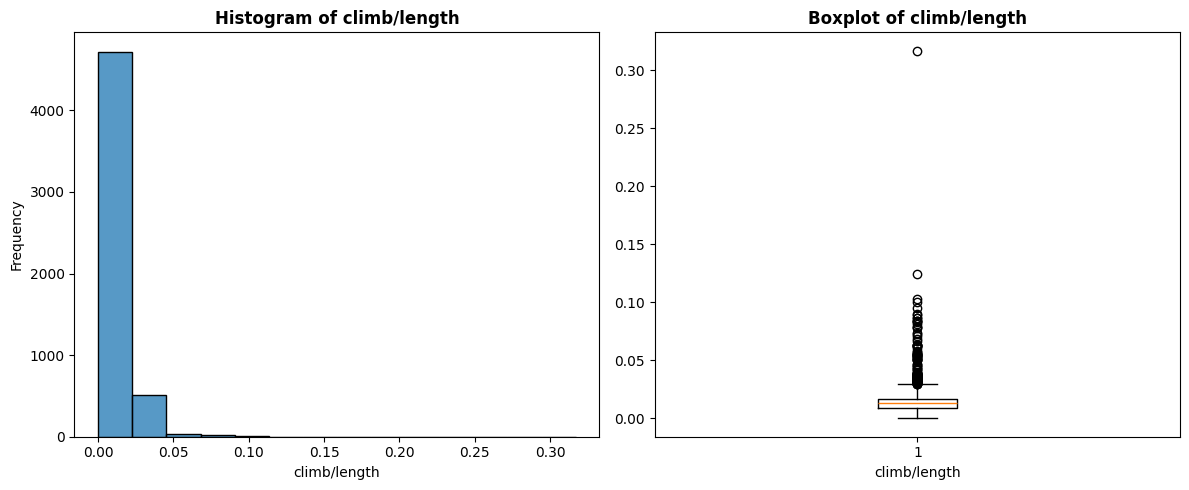

Outliers in climb/length: [np.float64(0.0355151515151515), np.float64(0.0625), np.float64(0.1032608695652173), np.float64(0.0509278350515463), np.float64(0.0380655737704918), np.float64(0.0314965517241379), np.float64(0.08975), np.float64(0.0300884955752212), np.float64(0.0321134751773049), np.float64(0.0417777777777777), np.float64(0.0365653710247349), np.float64(0.0527184466019417), np.float64(0.0712666666666666), np.float64(0.0316091954022988), np.float64(0.05821875), np.float64(0.08375), np.float64(0.0788888888888888), np.float64(0.0510163934426229), np.float64(0.0374453781512605), np.float64(0.0314410774410774), np.float64(0.0343589743589743), np.float64(0.0383529411764705), np.float64(0.0502364864864864), np.float64(0.0423391812865497), np.float64(0.0332473684210526), np.float64(0.0303030303030303), np.float64(0.0305527065527065), np.float64(0.0301204819277108), np.float64(0.095), np.float64(0.0426), np.float64(0.0726851851851851), np.float64(0.0357843137254901), np.float64(0.087

,Url,Column,Lower Bound,Upper Bound,Outlier Value
5,vuelta-a-espana/2017/stage-20,climb/length,0.0,0.03,0.032
18,giro-d-italia/2019/stage-14,climb/length,0.0,0.03,0.032
35,giro-d-italia/2004/stage-18,climb/length,0.0,0.03,0.032
37,vuelta-a-espana/2019/stage-9,climb/length,0.0,0.03,0.035
86,vuelta-a-espana/1993/stage-6,climb/length,0.0,0.03,0.034
...,...,...,...,...,...
5088,tour-de-france/1979/stage-2,climb/length,0.0,0.03,0.061
5161,tour-de-suisse/1976/prologue,climb/length,0.0,0.03,0.090
5169,vuelta-a-espana/1992/stage-9,climb/length,0.0,0.03,0.032
5175,tour-de-france/2021/stage-9,climb/length,0.0,0.03,0.032


Number of outliers in climb/length: 145


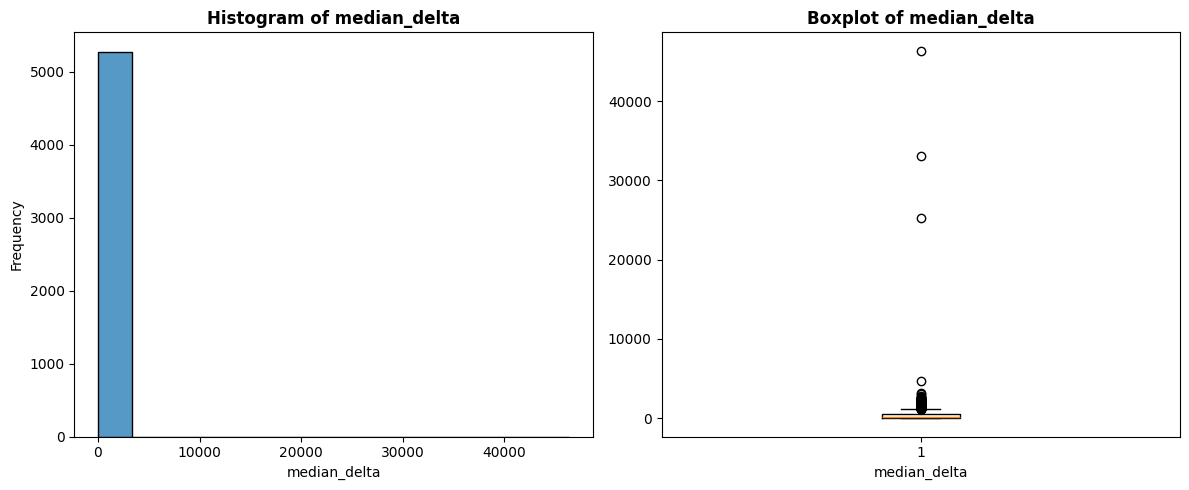

Outliers in median_delta: [np.float64(2048.0), np.float64(2060.0), np.float64(2062.0), np.float64(2072.0), np.float64(2080.0), np.float64(2083.0), np.float64(2090.0), np.float64(2101.0), np.float64(2109.5), np.float64(2120.0), np.float64(2126.0), np.float64(2140.0), np.float64(2154.0), np.float64(2156.0), np.float64(2169.0), np.float64(2185.0), np.float64(2191.0), np.float64(2193.0), np.float64(2199.0), np.float64(2208.0), np.float64(2210.0), np.float64(2216.0), np.float64(2244.0), np.float64(2274.5), np.float64(2365.0), np.float64(2368.5), np.float64(2370.0), np.float64(2373.0), np.float64(2399.0), np.float64(2419.0), np.float64(33140.0), np.float64(2426.0), np.float64(2500.0), np.float64(2562.0), np.float64(2657.0), np.float64(25223.0), np.float64(4751.0), np.float64(2732.0), np.float64(2825.0), np.float64(3018.0), np.float64(3234.0), np.float64(1187.0), np.float64(1189.0), np.float64(1193.0), np.float64(1194.0), np.float64(1195.0), np.float64(1199.0), np.float64(1200.0), np.float64(

,Url,Column,Lower Bound,Upper Bound,Outlier Value
1,vuelta-a-espana/2016/stage-14,median_delta,0.0,1186.25,1957.0
4,tour-de-france/2022/stage-9,median_delta,0.0,1186.25,1376.0
14,volta-a-catalunya/2015/stage-4,median_delta,0.0,1186.25,1669.0
18,giro-d-italia/2019/stage-14,median_delta,0.0,1186.25,1529.0
35,giro-d-italia/2004/stage-18,median_delta,0.0,1186.25,1423.0
...,...,...,...,...,...
5233,giro-d-italia/2015/stage-19,median_delta,0.0,1186.25,2562.0
5255,giro-d-italia/2021/stage-6,median_delta,0.0,1186.25,1287.5
5262,tour-de-romandie/2002/stage-2,median_delta,0.0,1186.25,1860.0
5266,dauphine/2015/stage-6,median_delta,0.0,1186.25,2185.0


Number of outliers in median_delta: 402


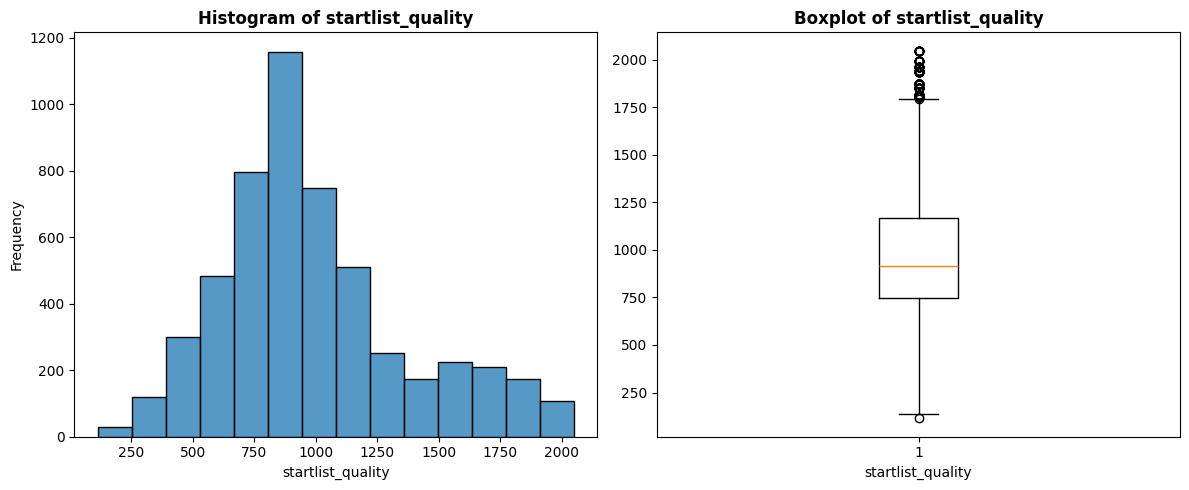

Outliers in startlist_quality: [np.int64(1794), np.int64(1959), np.int64(1994), np.int64(1804), np.int64(1933), np.int64(1871), np.int64(1872), np.int64(115), np.int64(1812), np.int64(1941), np.int64(1849), np.int64(2047)]


,Url,Column,Lower Bound,Upper Bound,Outlier Value
39,tour-de-france/1997/stage-15,startlist_quality,120.0,1792.0,1994
72,tour-de-france/1997/stage-2,startlist_quality,120.0,1792.0,1994
90,tour-de-france/1990/stage-1,startlist_quality,120.0,1792.0,1959
94,tour-de-france/1992/stage-7,startlist_quality,120.0,1792.0,2047
164,tour-de-france/1990/stage-9,startlist_quality,120.0,1792.0,1959
...,...,...,...,...,...
5125,tour-de-france/1987/stage-3,startlist_quality,120.0,1792.0,1812
5153,world-championship/1991/result,startlist_quality,120.0,1792.0,1794
5180,tour-de-france/1991/stage-19,startlist_quality,120.0,1792.0,1933
5190,tour-de-france/1997/stage-7,startlist_quality,120.0,1792.0,1994


Number of outliers in startlist_quality: 260


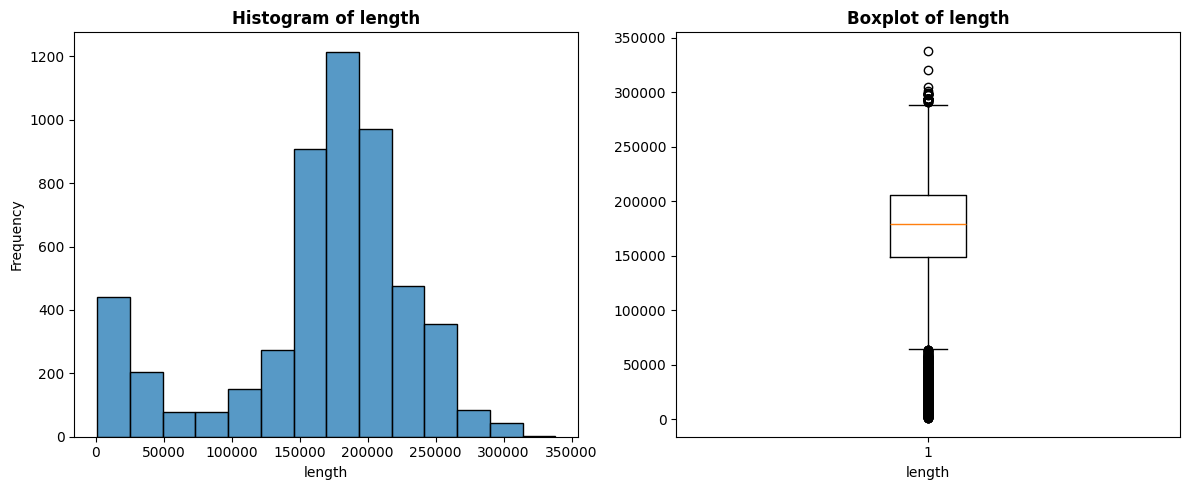

Outliers in length: [np.int64(4100), np.int64(59400), np.int64(8200), np.int64(12300), np.int64(63500), np.int64(16400), np.int64(20500), np.int64(24600), np.int64(36900), np.int64(41000), np.int64(297000), np.int64(53300), np.int64(6200), np.int64(61500), np.int64(14400), np.int64(18500), np.int64(26700), np.int64(30800), np.int64(338000), np.int64(34900), np.int64(39000), np.int64(4200), np.int64(6250), np.int64(59500), np.int64(12400), np.int64(16500), np.int64(20600), np.int64(24700), np.int64(37000), np.int64(293000), np.int64(6300), np.int64(57500), np.int64(10400), np.int64(14500), np.int64(18600), np.int64(26800), np.int64(30900), np.int64(35000), np.int64(291000), np.int64(55500), np.int64(4300), np.int64(8400), np.int64(12500), np.int64(33000), np.int64(37100), np.int64(41200), np.int64(53500), np.int64(6400), np.int64(22800), np.int64(26900), np.int64(31000), np.int64(8500), np.int64(12600), np.int64(18750), np.int64(49500), np.int64(6500), np.int64(18800), np.int64(27000), 

,Url,Column,Lower Bound,Upper Bound,Outlier Value
3,volta-a-catalunya/1999/prologue,length,64250.0,290250.0,8100
6,tour-de-france/1978/stage-14,length,64250.0,290250.0,52000
8,volta-a-catalunya/1981/stage-2b,length,64250.0,290250.0,30000
9,paris-nice/1994/stage-8b,length,64250.0,290250.0,12500
15,milano-sanremo/2004/result,length,64250.0,290250.0,294000
...,...,...,...,...,...
5241,milano-sanremo/2019/result,length,64250.0,290250.0,291000
5243,tour-de-france/1990/stage-5,length,64250.0,290250.0,301000
5244,milano-sanremo/1996/result,length,64250.0,290250.0,294000
5260,vuelta-a-espana/1997/stage-21,length,64250.0,290250.0,43000


Number of outliers in length: 749


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

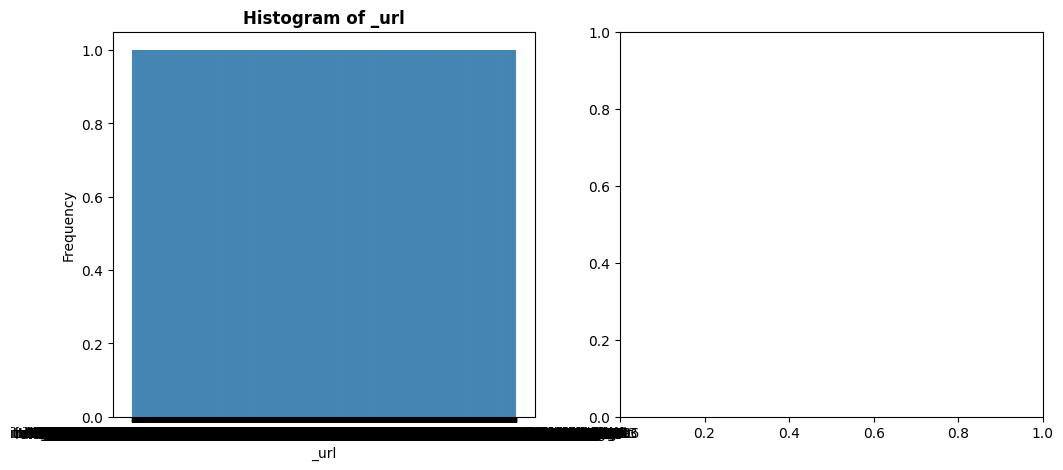

In [ ]:
for column in numeric_races_df:
    show_hist_and_box_plot(numeric_races_df,column)
    bounds = calculate_outlier_bounds(numeric_races_df, column)
    lower_bound = round(bounds['lower'], 3)
    upper_bound = round(bounds['upper'], 3)
    
    outliers_list = []
    outliers = numeric_races_df[
        (numeric_races_df[column] < lower_bound) | (numeric_races_df[column] > upper_bound)
    ]

    column_outliers_count = len(outliers)

    column_outliers_df = pd.DataFrame({
        "Url": outliers['_url'],
        "Column": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Value": outliers[column].round(3)
    })
    if(column_outliers_count > 0):
        display(column_outliers_df)
    print(f"Number of outliers in {column}: {column_outliers_count}")

## Data Normalization

In [ ]:
standardizer = standardize_fun(numeric_races_df)
standardized_races_df = standardizer['standardized_df']

## PCA
We apply Principal Component Analysis (PCA) to the standardized dataset (standardized_races_df) to reduce its dimensionality while preserving 90% of the variance. It calculates the number of principal components required to achieve this variance threshold and transforms the dataset into the PCA-reduced spac

In [ ]:
pca_instance = PCA(n_components=0.90)  # Preserve 90% of the variance
pca_std_numeric_races = pca_instance.fit_transform(standardized_races_df)

print(f"# selected principal components: {pca_instance.n_components_}")

In [ ]:
# pca = PCA()
# pca.fit(standardized_races_df) 

# # Compute the contribution (loadings) of each feature to each principal component
# loadings = pd.DataFrame(
#     pca.components_.T, # Transpose to align features with components
#     columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Label columns as PC1, PC2, etc.
#     index=numeric_races_df.columns # Use feature names as index
# )

# display(loadings)

# # Calculate the importance of each feature based on the first two principal components
# top_components = loadings.iloc[:, :2].abs().sum(axis=1) 
# top_variables = top_components.sort_values(ascending=False)


# print("\nFeatures sorted by contribution:")
# print(top_variables)


# selected_columns = top_variables.index.tolist()
# print(f"\nSelected columns: {selected_columns}")


## Kmeans grid search

In [ ]:
results = kmeans_grid_search(pca_std_numeric_races)

In [ ]:
k_means_evaluation_plotting(results)

## Compute Kmeans algorithm with best K found
Analyzing the Elbow Method of SSE and the Silhouette Score, the optimal  k  values do not align. The Silhouette Score suggests  k = 5  as the optimal number of clusters, while the SSE indicates  k = 6  or  k = 7 . As a trade-off, we choose  k = 6 .

In [ ]:
kmeans_data = kmeans_run(data=pca_std_numeric_races, best_k=6, scaler=standardizer['scaler'])
best_kmeans = kmeans_data['best_kmeans']
centroids = kmeans_data['centroids']

In [ ]:
# count points for each cluster
cluster_counts = pd.Series(best_kmeans.labels_).value_counts().sort_index()

print("Number of points for each cluster")
print(cluster_counts)

In [ ]:
numeric_races_df = numeric_races_df.copy() 
# Add Cluster as a column to the dataset
numeric_races_df['Cluster'] = best_kmeans.labels_

# Compute statistics for each feature grouped by cluster
detailed_cluster_stats = numeric_races_df.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])

detailed_cluster_stats.columns = ['_'.join(col) for col in detailed_cluster_stats.columns]

display(detailed_cluster_stats)


## Distribution of points for each feature across clusters

In [ ]:
clusters_box_plot(numeric_races_df)

### Box-plots analysis

By analying the box-plots above, we can try to analyze the 6 clusters by considering points distribution for each feature:
- **Cluster 0** (2721 points): 
  
  - **_points_**: the median is relatively low, ~50, and the IQR is narrow, ranging from ~50 up to ~80. There are few outliers on ~150.
  
  - **_climb/lenght_**: median is about ~0.01 and there are some outliers extending up to ~0.03.

  - **_median\_delta_**: IQR is extremely narrow and median is ~100, with a lot of high-end outliers up to ~2000. 

  - **_startlist\_quality_**:  IQR ranges from ~700 to ~ 900 with a median value of about ~ 850. There are many low-end outliers close to ~100.

  - **_length_**: here we have a relatively tight IQR, ~[160000, 200000], with a median on about ~180000. There are some low-end outliers and many high-end outliers up to ~2900000.

- **Cluster 1** (563 points): 
  
  - **_points_**: IQR is similar to the ones of the Cluster 0, slighlty higher with a median ~80. No outliers spotted here.
  
  - **_climb/lenght_**: this cluster has the highest ratio climb/length, meaning that Cluster 1 has the largest number of steep races with a median value about ~0.03. There are many outliers in the upper end, with some of these extending beyond 0.30. 

  - **_median\_delta_**: IQR is higher and wider than the one in Cluster 0. Also here, there are some high-end outliers exteding up to ~50000.
  
  - **_startlist\_quality_**: IQR is relatively wide and it extends from ~900 to ~1250 and the median is ~1000. So races in this cluster are attended by "stronger" cyclists compared to the Cluster 0. There are outliers on both the lower and the upper part, reaching over 2000.

  - **_length_**: races of this cluster are shorter than the ones in Cluster 0. The IQR is the widest, ranging from ~130000 to ~180000, and the median length is about ~160000. There are many low-end outlier lower ~10000.
  
- **Cluster 2** (3 points): extremely little cluster, 3 only points. It makes no sense to do analysis on this cluster. What is immediately noticeable is that it contains races with much higher values of median_delta compared to the other clusters.
  
- **Cluster 3** (704 points):
  
  - **_points_**: IQR here is approximately the same as ones in Cluster 0 and Cluster 1. There are no outliers.
  
  - **_climb/lenght_**: IQR and median very similar to the ones in Cluster 0. There are some high-end outliers, up to ~0.04.

  - **_median\_delta_**: this cluster has the narrowest IQR, and some high-end outliers.
  
  - **_startlist\_quality_**: IQR is relatively wide, with a median value of ~850. Many outliers reside in the upper part, extending up to ~1900.

  - **_length_**: the races in this cluster are the shortest, with a median of ~20000. Some outliers extend beyond 100000.
  
- **Cluster 4** (509 points):
  
  - **_points_**: the highest number of points are awarded to races in this cluster. The median number of points is ~275. There are no outliers.
  
  - **_climb/lenght_**: IQR is narrower than that of Cluster 3, and the median is slightly higher. There are no outliers.

  - **_median\_delta_**: IQR is slightly higher compared to the ones of Cluster 0 and Cluster 3. There are some outliers in the upper part.
  
  - **_startlist\_quality_**: IQR here is the widest, with a range between ~740 and ~1150 and a median value of about ~870. There are no outliers.

  - **_length_**: the races in this cluster are the longest, with a median beyond 250000. There are some low-end outliers close to ~175000.
  
 - **Cluster 5** (781 points):
  
  - **_points_**: IQR is the narrowest here, showing relatively low variability in points. The median value is also the max value, and it is approximately ~100. There are some low-end outliers, the lowest is approximately ~50.
  
  - **_climb/lenght_**: IQR is pretty similar to the ones of Cluster 0 and Cluster 3. Also here there are outliers in the upper part.

  - **_median\_delta_**: in this cluster median_delta IQR is the second widest, behind only that of cluster 1. Median is approximately ~100.
  
  - **_startlist\_quality_**: the races here have the highest startlist_quality values, meaning that these races are attended by the strongest cyclists. IQR ranges from about ~1500 to ~1850 with a median value of ~1700. There are no outliers.

  - **_length_**: the IQR is relatively wide, ranging from ~170000 to ~220000 with a median of ~190000. There are a lot of outliers on both the lower and the upper part. The minimum outlier is about ~5000 and the maximum is just under 350000.

Based on the analysis provided, here’s what we can infer about the clusters:
#### Cluster 0
Cluster 0 represents the most prevalent race type in the dataset. These races are of relatively low importance, with modest points awarded to participants. They are predominantly flat, and have minimal climbing challenges. The startlist quality is average, with most races attracting mid-level cyclists. The race lengths are moderate. Overall, Cluster 0 contains, let's say, standard races.

#### Cluster 1
Cluster 1 includes races which have the highest climb/length ratios. While the races are not excessively long, they attract stronger cyclists than Cluster 0, given the higher the startlist quality values. These races are likely to be shorter and with more climbs.

#### Cluster 2
Too few points to draw any conclusions

#### Cluster 3
Cluster 3 contains the shortest races with predominantly flat profiles. These races are quite competitive, with close finishes and minimal performance variability. The short race lengths suggest that these are likely criteriums or one-day events.

#### Cluster 4
Cluster 4 consists of highly prestigious races that reward participants with the highest number of points. These races are characterized by long distances and moderate climbing intensity. This cluster likely includes high-value stage races that offer significant rewards.

#### Cluster 5
Cluster 5 contains races that stand out for their high startlist quality, attracting the strongest cyclists in the dataset. These races are mid-length and predominantly flat. Points are moderately high but not as significant as in Cluster 4. The variability in race lengths and the outcomes (median_delta) is higher than in other clusters. These races are the ones in which the best cyclists compete.

## Clusters visualization with feature distributions and centroids 

In [ ]:
clusters_pairplot(numeric_races_df, centroids)

### Pairplot analysis

By analyzing the paiplot above, we can try to analyze the 6 clusters and try to catch any relationships and patterns between the characteristics of the clusters that we were unable to catch with the box plots

- **Cluster 0**: no clear relationships or patterns identified

- **Cluster 1**:
  - **_climb\_length_** vs **length**: as length increases, there is a weak tendency for climb/length to decrese, which may suggest that longer races are slightly flatter or have less climbing intensity in this cluster.
  
- **Cluster 2**: too few point to get an effective analysis from the pairplot
  
- **Cluster 3**:
  - **_startlist\_quality** vs **length** it seems there is a subtle relationship between those two features in Cluster 3. This is a negative relation, as the length of the races increases, the quality of the starting list tends to decrease.
  
- **Cluster 4**: 
  - **_points_** vs **_length_**:	there seems to be a weak correlation: as the length increases, points also increase slightly. So, longer races tend to give more points.

  - **_points_** vs **_startlist\_quality_**: higher points values in this cluster align with slightly higher statirst_quality.
  
  - **_length_** vs **_startlist\_quality_**: there seems to be a very weak positive correlation, especially for startirst_quality > 1000, where length of the races tends to increase with the quality of the starting list.
	
- **Cluster 5**:
  - **_points_** vs **_startlist\_quality_**: there is a very subtle relation, higher points values align with slightly higher statirst_quality.
  
  - **_startlist\_quality** vs **length**: also in this cluster seems to be a negative correlation between those two features. With better (higher) quality of the starting list, the length of the races seems to decrease.
 



 